# 因子選股策略回測：完整流程（取得資料 → Phase 1~4 SOP）

從資料庫取資料開始，依序執行 Phase 1（單因子健檢）→ Phase 2（F1×F2配對）→
Phase 3（加動態條件C）→ Phase 4（加估值濾網V）。

程式邏輯跟 `code/phase1_*.py`~`phase4_*.py` 完全一致（本notebook呼叫那些程式，
不是另外重寫一份），跑出來的結果跟直接用命令列執行相同。

由上而下依序執行每個 code cell 即可。


## 0.5 選擇市場

**整份 notebook 只需要改下面這一格**，其餘所有 cell 都會自動套用，不用再逐格修改 `--market`。


In [40]:
MARKET = 'TW'  # 'TW' 或 'US'，改這裡切換整份 notebook 要跑哪個市場


## 0.6 選擇日期範圍

**同樣整份 notebook 只需要改下面這一格**。維持下面的預設值＝跟正式結果完全相同的
2000-01-01~2025-12-31 in-sample 範圍，其餘流程不受影響。

改成別的日期範圍時，Phase 1~4 的輸出會自動改用獨立的檔名（自動加上日期後綴），
**不會覆蓋掉正式結果**。但要注意跟本來就有的「先跑完前一階段」執行順序一樣，
Phase 2/3/4 需要讀取同一組日期下、前一階段已經跑過的結果——換日期後，
要從 Phase 1 開始依序重跑一次同一組 `START_DATE`/`END_DATE`。


In [41]:
START_DATE = '2000-01-01'  # in-sample 起始日期，改這裡切換整份 notebook 要跑哪個日期範圍
END_DATE = '2025-12-31'    # in-sample 結束日期（2026年以後保留為樣本外，不建議超過這個範圍）


In [42]:
from sweep_config import date_range_suffix, MARKET_START
from phase1_linearity import IN_SAMPLE_END

# RSFX：自訂日期範圍時的檔名後綴，下面「看結果」的 cell 讀檔會用到。
# 維持預設日期時 RSFX 是空字串，讀的檔名跟原本完全一樣。
RSFX = date_range_suffix(START_DATE, END_DATE, MARKET_START[MARKET], IN_SAMPLE_END)
print('RSFX =', repr(RSFX) or '（空字串，維持預設日期範圍的檔名）')


RSFX = ''


## 0.7 取得這個日期範圍的大盤


In [43]:
from pathlib import Path

bench_path = Path(f'results_artifacts/{MARKET}_UNIVERSE_M{RSFX}/stats.parquet')
if bench_path.exists():
    print(f'✓ 此日期範圍的大盤已存在，跳過：{bench_path}')
else:
    print(f'尚未建立此日期範圍的大盤，開始建立：{bench_path}')
    get_ipython().run_line_magic(
        'run', f'universe_benchmark.py --market {MARKET} --start {START_DATE} --end {END_DATE}')


✓ 此日期範圍的大盤已存在，跳過：results_artifacts\TW_UNIVERSE_M\stats.parquet


## 1. 取得資料

回測引擎透過 `fcv_core.MarketData` 一次載入某個市場的價量+財報資料，
Phase 1~4 重複使用這份已載入的資料。

`MarketData` 做的事：
1. 呼叫 `get_data.Data(market=...)` 從資料庫抓股價、財報、因子原始資料。
2. 回測宇宙＝「有因子資料」∩「有股價資料」的股票交集。
3. 依 `start`/`end` 參數把資料裁到 in-sample 範圍（2000-01-01~2025-12-31，
   2026年之後保留當作樣本外，不用來訓練/篩選，避免用到未來資訊）。


In [44]:
from fcv_core import MarketData

md_demo = MarketData(market=MARKET, start=START_DATE, end=END_DATE)

close = md_demo.data.get('price:close')
print('股價資料形狀（交易日 x 股票數）：', close.shape)
close.tail()


>> 載入 Data(market='TW') ...
   因子宇宙=1789｜回測宇宙=1789｜起點>=2000-01-01｜終點<=2025-12-31｜交易日=6428 (2000-01-04~2025-12-31)｜耗時 108s
股價資料形狀（交易日 x 股票數）： (6428, 1789)


company_symbol,1101,1102,1103,1104,1108,1109,1110,1201,1203,1210,...,9944,9945,9946,9949,9950,9951,9955,9958,9960,9962
date,,,,,,,,,,,,,,,,,,,,,
2025-12-24,21.8482,34.0409,13.4524,28.2233,13.8124,14.5478,16.0425,14.4068,39.40,50.9,...,16.7143,29.2819,19.15,25.1838,10.50,55.6,31.00,133.104,21.30,10.05
2025-12-26,22.0416,34.2744,13.4524,28.0829,13.8588,14.5947,16.2387,14.4068,39.75,50.7,...,16.7143,29.3298,19.10,25.2757,10.45,55.6,31.55,133.104,21.50,10.05
2025-12-29,22.5249,34.3678,13.5004,28.0361,13.8588,14.5947,16.3859,14.4068,40.15,51.4,...,16.7143,28.8985,19.15,25.2757,10.25,55.5,31.80,135.026,21.25,10.15
2025-12-30,22.8150,34.6480,13.4524,28.0829,13.8124,14.5478,16.2387,14.3576,40.05,51.0,...,16.6651,28.7547,19.15,25.1379,10.40,55.3,31.10,133.584,21.25,10.15
2025-12-31,22.4283,34.7414,13.4044,28.0829,13.8588,14.5478,16.2387,14.3085,39.75,50.9,...,16.7634,28.5630,19.20,25.5515,10.60,55.5,30.50,134.065,21.45,10.35


In [45]:
roe = md_demo.get_field('report:ROE')
print('ROE 資料形狀：', roe.shape if roe is not None else None)

md_demo.release()   # 釋放快取


ROE 資料形狀： (6428, 1789)


⚠️ 下面 Phase 1~4 的每個腳本都是各自獨立可執行的程式，執行時會**各自重新呼叫一次
`MarketData` 重新載入資料**，不會共用上面這個demo載入的 `md_demo`。


## 2. Phase 1：單因子線性檢定

每個候選因子單獨切成 9 個分位桶（q_band），不搭配其他因子、不加動態條件，
檢查報酬是否隨分位單調變化（Spearman ρ）。未通過線性檢定的因子不會用於後續
Phase 2~4 的 primary 因子。

因子池 20 個（PE 保留給 Phase 4 估值濾網使用，不在此因子池內）。
先 `--dry-run` 看預期跑幾個策略：


In [46]:
%run phase1_linearity.py --market $MARKET --start $START_DATE --end $END_DATE --dry-run


[2026-08-28 00:10:29] === Phase 1 線性檢定｜市場=TW｜因子數=20｜分桶 N=9｜V=('v0',)（F2/C 皆關閉）｜期間 2000-01-01~2025-12-31 ===
[2026-08-28 00:10:29]     done     TW_L1_ROE_M            P1= 9 P3= 0 → 預期 9 策略
[2026-08-28 00:10:29]     done     TW_L1_EPS_M            P1= 9 P3= 0 → 預期 9 策略
[2026-08-28 00:10:29]     done     TW_L1_FCF_P_M          P1= 9 P3= 0 → 預期 9 策略
[2026-08-28 00:10:29]     done     TW_L1_DEBTRATIO_M      P1= 9 P3= 0 → 預期 9 策略
[2026-08-28 00:10:29]     done     TW_L1_REVENUE_M        P1= 9 P3= 0 → 預期 9 策略
[2026-08-28 00:10:29]     done     TW_L1_EV_EBITDA_M      P1= 9 P3= 0 → 預期 9 策略
[2026-08-28 00:10:29]     done     TW_L1_EV_S_M           P1= 9 P3= 0 → 預期 9 策略
[2026-08-28 00:10:29]     done     TW_L1_PB_M             P1= 9 P3= 0 → 預期 9 策略
[2026-08-28 00:10:29]     done     TW_L1_PS_M             P1= 9 P3= 0 → 預期 9 策略
[2026-08-28 00:10:29]     done     TW_L1_P_IC_M           P1= 9 P3= 0 → 預期 9 策略
[2026-08-28 00:10:29]     done     TW_L1_ROIC_M           P1= 9 P3= 0 → 預期 9 策略
[2026-08-28 

確認數字合理後，拿掉 `--dry-run` 真的執行（9桶×20因子×2個V模式，約數百個策略，
通常數分鐘內可完成）：


In [47]:
%run phase1_linearity.py --market $MARKET --start $START_DATE --end $END_DATE


[2026-08-28 00:10:29] === Phase 1 線性檢定｜市場=TW｜因子數=20｜分桶 N=9｜V=('v0',)（F2/C 皆關閉）｜期間 2000-01-01~2025-12-31 ===
[2026-08-28 00:10:29]     done     TW_L1_ROE_M            P1= 9 P3= 0 → 預期 9 策略
[2026-08-28 00:10:29]     done     TW_L1_EPS_M            P1= 9 P3= 0 → 預期 9 策略
[2026-08-28 00:10:29]     done     TW_L1_FCF_P_M          P1= 9 P3= 0 → 預期 9 策略
[2026-08-28 00:10:29]     done     TW_L1_DEBTRATIO_M      P1= 9 P3= 0 → 預期 9 策略
[2026-08-28 00:10:29]     done     TW_L1_REVENUE_M        P1= 9 P3= 0 → 預期 9 策略
[2026-08-28 00:10:29]     done     TW_L1_EV_EBITDA_M      P1= 9 P3= 0 → 預期 9 策略
[2026-08-28 00:10:29]     done     TW_L1_EV_S_M           P1= 9 P3= 0 → 預期 9 策略
[2026-08-28 00:10:29]     done     TW_L1_PB_M             P1= 9 P3= 0 → 預期 9 策略
[2026-08-28 00:10:29]     done     TW_L1_PS_M             P1= 9 P3= 0 → 預期 9 策略
[2026-08-28 00:10:29]     done     TW_L1_P_IC_M           P1= 9 P3= 0 → 預期 9 策略
[2026-08-28 00:10:29]     done     TW_L1_ROIC_M           P1= 9 P3= 0 → 預期 9 策略
[2026-08-28 

用 `phase1_analyze.py` 分析健檢結果——算每個因子的 Spearman ρ、判定有沒有線性、
畫出9桶報酬曲線圖，輸出到 `../_analysis_outputs_phase1/`：


In [48]:
%run phase1_analyze.py --market $MARKET --start $START_DATE --end $END_DATE


基準 = 8.43%｜期間 2000-01-01~2025-12-31

載入規模參照（REVENUE_qb0）以計算重疊診斷 …
===== Phase 1 線性檢定結果 =====
            因子  Spearman_rho     p值       形狀       判定  最佳桶  最佳桶CAGR   全桶均值  贏大盤桶數  最佳桶與最小規模重疊
          P_IC        -1.000 0.0000      單調↓     ✅ 過關    0   0.1985 0.1070      5       0.047
            PB        -0.983 0.0000      單調↓     ✅ 過關    0   0.2205 0.1063      5       0.060
            PS        -0.983 0.0000      單調↓     ✅ 過關    0   0.1948 0.1073      5       0.011
          EV_S        -0.950 0.0001      單調↓     ✅ 過關    0   0.1675 0.1077      6       0.023
           MOM         0.933 0.0002      單調↑     ✅ 過關    7   0.1135 0.0760      4       0.072
         OCF_E         0.883 0.0016      單調↑     ✅ 過關    8   0.1090 0.0901      6       0.051
         FCF_P         0.483 0.1875 U型（兩端最好） ⚠️ 只取極端桶    8   0.1283 0.0989      6       0.059
           ROE         0.833 0.0053 倒U（中間最好）    ⚠️ 邊際    6   0.1060 0.0913      8       0.032
     EV_EBITDA        -0.817 0.0072 倒U（中間最好）    ⚠️ 邊際    2   

看結果——每個因子的線性判定表，跟9桶報酬曲線圖：

,因子,Spearman_rho,p值,形狀,判定,最佳桶,最佳桶CAGR,最差桶CAGR,全桶均值,贏大盤桶數,最佳桶與最小規模重疊,桶0,桶1,桶2,桶3,桶4,桶5,桶6,桶7,桶8
0,P_IC,-1.000,0.0000,單調↓,✅ 過關,0,0.1985,0.0305,0.1070,5,0.047,0.1985,0.1648,0.1545,0.1137,0.1062,0.0831,0.0701,0.0418,0.0305
1,PB,-0.983,0.0000,單調↓,✅ 過關,0,0.2205,0.0362,0.1063,5,0.060,0.2205,0.1590,0.1422,0.1290,0.0998,0.0685,0.0637,0.0362,0.0379
2,PS,-0.983,0.0000,單調↓,✅ 過關,0,0.1948,0.0605,0.1073,5,0.011,0.1948,0.1562,0.1246,0.1226,0.0917,0.0785,0.0762,0.0605,0.0606
3,EV_S,-0.950,0.0001,單調↓,✅ 過關,0,0.1675,0.0555,0.1077,6,0.023,0.1675,0.1486,0.1383,0.1171,0.1092,0.0903,0.0623,0.0555,0.0807
4,MOM,0.933,0.0002,單調↑,✅ 過關,7,0.1135,0.0238,0.0760,4,0.072,0.0238,0.0437,0.0645,0.0637,0.0689,0.0937,0.1066,0.1135,0.1055
5,OCF_E,0.883,0.0016,單調↑,✅ 過關,8,0.1090,0.0635,0.0901,6,0.051,0.0707,0.0635,0.0826,0.0931,0.0957,0.1007,0.1007,0.0950,0.1090
6,FCF_P,0.483,0.1875,U型（兩端最好）,⚠️ 只取極端桶,8,0.1283,0.0748,0.0989,6,0.059,0.1233,0.0790,0.0748,0.0751,0.0914,0.0956,0.1022,0.1204,0.1283
7,ROE,0.833,0.0053,倒U（中間最好）,⚠️ 邊際,6,0.1060,0.0623,0.0913,8,0.032,0.0623,0.0880,0.0922,0.0863,0.0909,0.0980,0.1060,0.0978,0.1004
8,EV_EBITDA,-0.817,0.0072,倒U（中間最好）,⚠️ 邊際,2,0.1667,0.0481,0.1024,6,0.024,0.0948,0.1555,0.1667,0.1417,0.1105,0.0916,0.0640,0.0482,0.0481
9,ROIC,0.700,0.0358,倒U（中間最好）,⚠️ 邊際,7,0.1047,0.0626,0.0915,8,0.044,0.0626,0.0865,0.0926,0.0932,0.0989,0.0989,0.0903,0.1047,0.0956


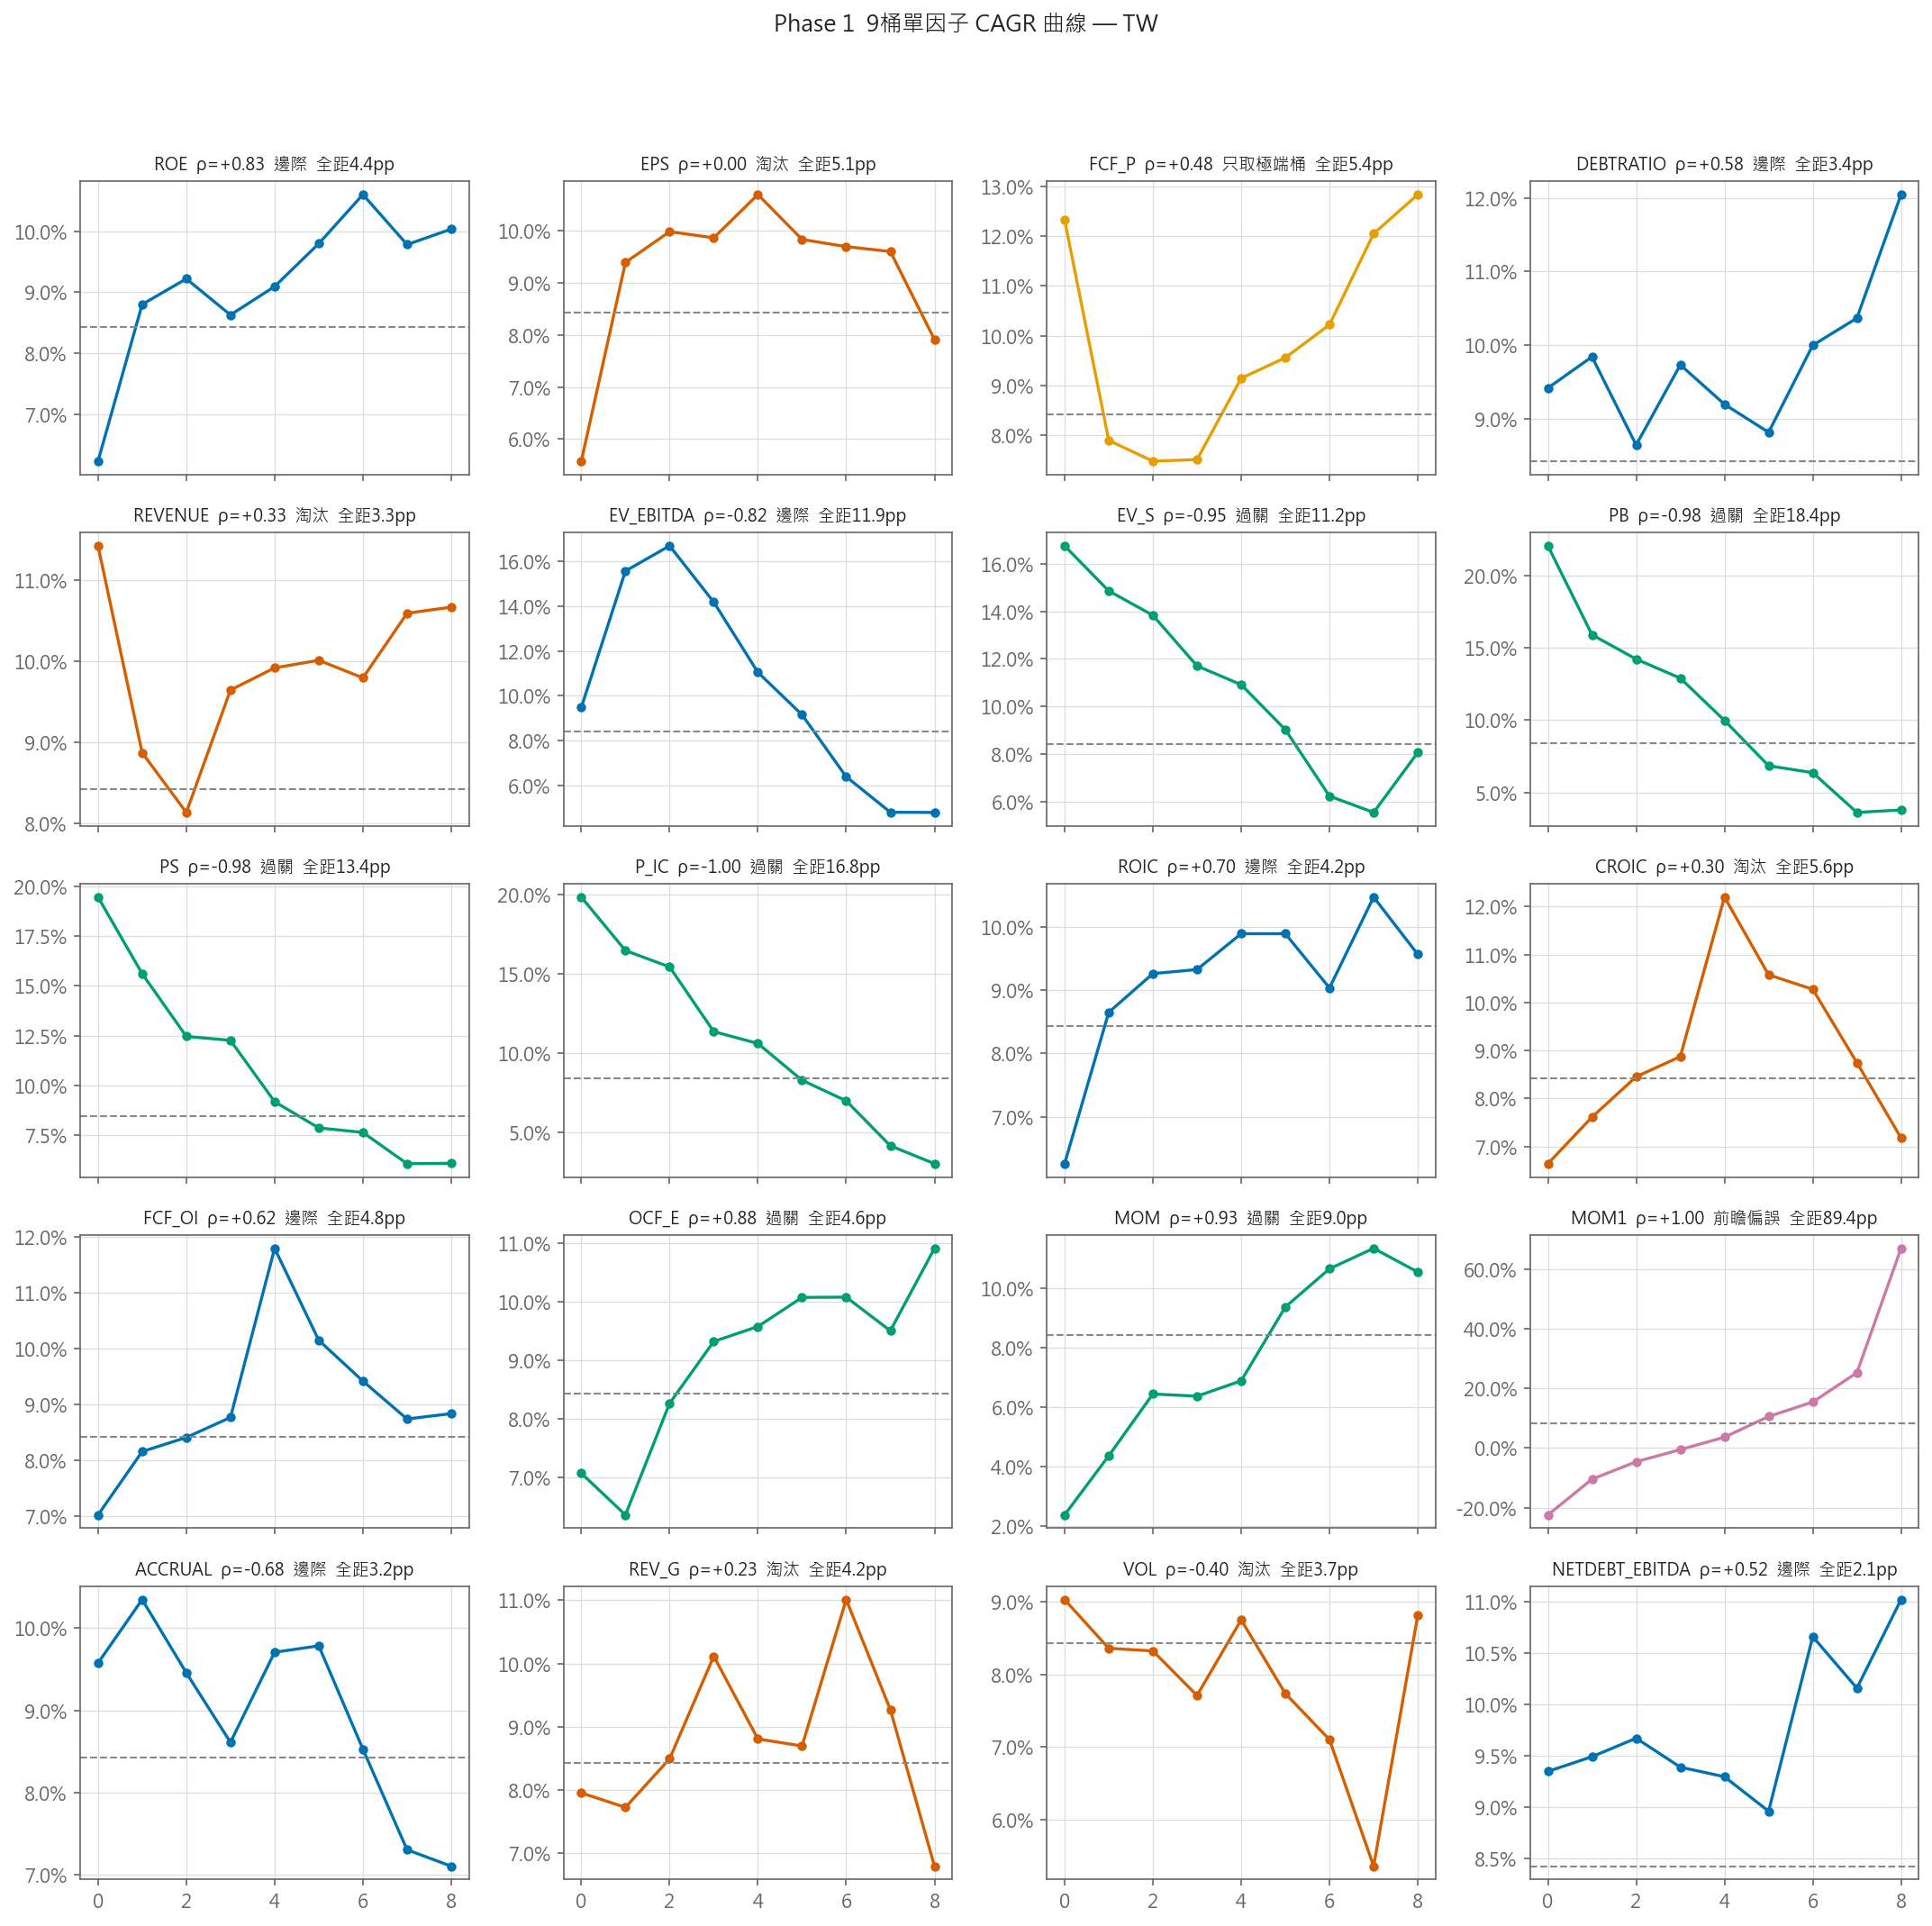

In [49]:
import pandas as pd
from IPython.display import Image, display

df = pd.read_csv(f'../_analysis_outputs_phase1/{MARKET}_phase1{RSFX}_linearity.csv')
display(df)
display(Image(f'../_analysis_outputs_phase1/{MARKET}_phase1{RSFX}_curves.png'))


## 3. Phase 2：F1×F2 不對稱配對

Phase 1 通過線性檢定的因子分成 primary（嚴格門檻）／secondary（寬鬆）。
`--variant openSec`：primary 用嚴格標準篩，secondary 全部開放。


In [50]:
%run phase2_pairing.py --market $MARKET --variant openSec --start $START_DATE --end $END_DATE --dry-run


[2026-08-28 00:10:33] === Phase 2 配對｜市場=TW｜因子=19（primary 6 / secondary 19）｜分桶 N=3｜V=('v0',)（C 關閉）｜期間 2000-01-01~2025-12-31 ===
[2026-08-28 00:10:33]     primary  ：['P_IC', 'PB', 'PS', 'EV_S', 'MOM', 'OCF_E']
[2026-08-28 00:10:33]     secondary：['P_IC', 'PB', 'PS', 'EV_S', 'MOM', 'OCF_E', 'FCF_P', 'ROE', 'EV_EBITDA', 'ROIC', 'ACCRUAL', 'FCF_OI', 'DEBTRATIO', 'NETDEBT_EBITDA', 'VOL', 'REVENUE', 'CROIC', 'REV_G', 'EPS']
[2026-08-28 00:10:33]     P1 條件數=57｜單因子=57｜跨因子配對=1539｜預期共 1596 策略
[2026-08-28 00:10:33]     done  TW_L2_all_M
[2026-08-28 00:10:33] dry-run：不執行。


拿掉 `--dry-run` 真的執行（F1×F2 兩兩配對，策略數比 Phase 1 多，通常數十分鐘等級）：


In [51]:
%run phase2_pairing.py --market $MARKET --variant openSec --start $START_DATE --end $END_DATE


[2026-08-28 00:10:33] === Phase 2 配對｜市場=TW｜因子=19（primary 6 / secondary 19）｜分桶 N=3｜V=('v0',)（C 關閉）｜期間 2000-01-01~2025-12-31 ===
[2026-08-28 00:10:33]     primary  ：['P_IC', 'PB', 'PS', 'EV_S', 'MOM', 'OCF_E']
[2026-08-28 00:10:33]     secondary：['P_IC', 'PB', 'PS', 'EV_S', 'MOM', 'OCF_E', 'FCF_P', 'ROE', 'EV_EBITDA', 'ROIC', 'ACCRUAL', 'FCF_OI', 'DEBTRATIO', 'NETDEBT_EBITDA', 'VOL', 'REVENUE', 'CROIC', 'REV_G', 'EPS']
[2026-08-28 00:10:33]     P1 條件數=57｜單因子=57｜跨因子配對=1539｜預期共 1596 策略
[2026-08-28 00:10:33]     done  TW_L2_all_M
[2026-08-28 00:10:33] 已完成（且因子池相同），無待跑。


In [52]:
%run phase2_analyze.py --market $MARKET --variant openSec --start $START_DATE --end $END_DATE


變體＝openSec：修正版：primary 維持 Phase 1 過關者，secondary 開放全部
  primary  (6)：['P_IC', 'PB', 'PS', 'EV_S', 'MOM', 'OCF_E']
  secondary(19)：['P_IC', 'PB', 'PS', 'EV_S', 'MOM', 'OCF_E', 'FCF_P', 'ROE', 'EV_EBITDA', 'ROIC', 'ACCRUAL', 'FCF_OI', 'DEBTRATIO', 'NETDEBT_EBITDA', 'VOL', 'REVENUE', 'CROIC', 'REV_G', 'EPS']
基準＝8.43%
門檻：primary 需 > 基準+2%｜secondary 需 > 基準−1%｜配對退步容忍 0.5%｜平均持股數 ≥ 10

讀入 1596 個策略（單因子 57／配對 1539）
計算持股數三項指標（平均／覆蓋率／p10）…

可當 primary 的 (因子,桶)：10 個
   F1  k1     CAGR      贏大盤      平均持股數
   PB   0 0.180509 0.096253 463.010101
 P_IC   0 0.178674 0.094419 463.010101
   PS   0 0.164345 0.080089 462.636364
 EV_S   0 0.157036 0.072780 460.215488
  MOM   2 0.115171 0.030915 434.922078
 EV_S   1 0.112615 0.028359 460.316498
 P_IC   1 0.107749 0.023493 463.329966
OCF_E   2 0.107025 0.022769 506.670034
   PB   1 0.105992 0.021736 463.329966
   PS   1 0.104545 0.020290 463.020202

===== 晉升結果 =====
  總策略 1596｜晉升 218｜未晉升 1378

未晉升原因分布：
未過原因
兩邊都不具 primary 資格                    1040
配對後退步過多      

看結果——配對後的體質檢查表（前10筆），跟配對增益分布圖：

,strategy,primary,secondary,CAGR,primary_solo_CAGR,配對增益,max_drawdown,win_ratio,平均持股數,持股月份覆蓋率,持股數p10,晉升,未過原因
0,P_IC_qb0of3__REVENUE_qb0of3__None__v0,P_IC_qb0,REVENUE_qb0,0.228413,0.178674,0.049738,-0.527045,0.571291,95.424242,1.0,32.0,True,NaN
1,P_IC_qb0of3__VOL_qb2of3__None__v0,P_IC_qb0,VOL_qb2,0.212954,0.178674,0.034279,-0.664951,0.502044,122.626263,1.0,99.0,True,NaN
2,P_IC_qb0of3__ROE_qb2of3__None__v0,P_IC_qb0,ROE_qb2,0.209730,0.178674,0.031056,-0.466260,0.517895,68.528620,1.0,7.0,True,NaN
3,PB_qb0of3__ROE_qb2of3__None__v0,PB_qb0,ROE_qb2,0.206699,0.180509,0.026190,-0.442233,0.518032,45.020202,1.0,4.0,True,NaN
4,PB_qb0of3__ROIC_qb2of3__None__v0,PB_qb0,ROIC_qb2,0.206451,0.180509,0.025942,-0.459109,0.510376,47.540146,1.0,6.0,True,NaN
5,P_IC_qb0of3__DEBTRATIO_qb0of3__None__v0,P_IC_qb0,DEBTRATIO_qb0,0.203907,0.178674,0.025233,-0.566324,0.598131,50.306397,1.0,25.0,True,NaN
6,PB_qb0of3__REVENUE_qb0of3__None__v0,PB_qb0,REVENUE_qb0,0.200545,0.180509,0.020036,-0.550972,0.612697,122.033670,1.0,44.0,True,NaN
7,EV_S_qb0of3__REVENUE_qb0of3__None__v0,EV_S_qb0,REVENUE_qb0,0.198987,0.157036,0.041951,-0.438581,0.562095,70.484848,1.0,21.0,True,NaN
8,PB_qb0of3__VOL_qb2of3__None__v0,PB_qb0,VOL_qb2,0.198216,0.180509,0.017707,-0.655380,0.494366,113.141414,1.0,87.0,True,NaN
9,PS_qb0of3__REVENUE_qb0of3__None__v0,PS_qb0,REVENUE_qb0,0.195898,0.164345,0.031553,-0.774243,0.512975,54.168350,1.0,17.0,True,NaN


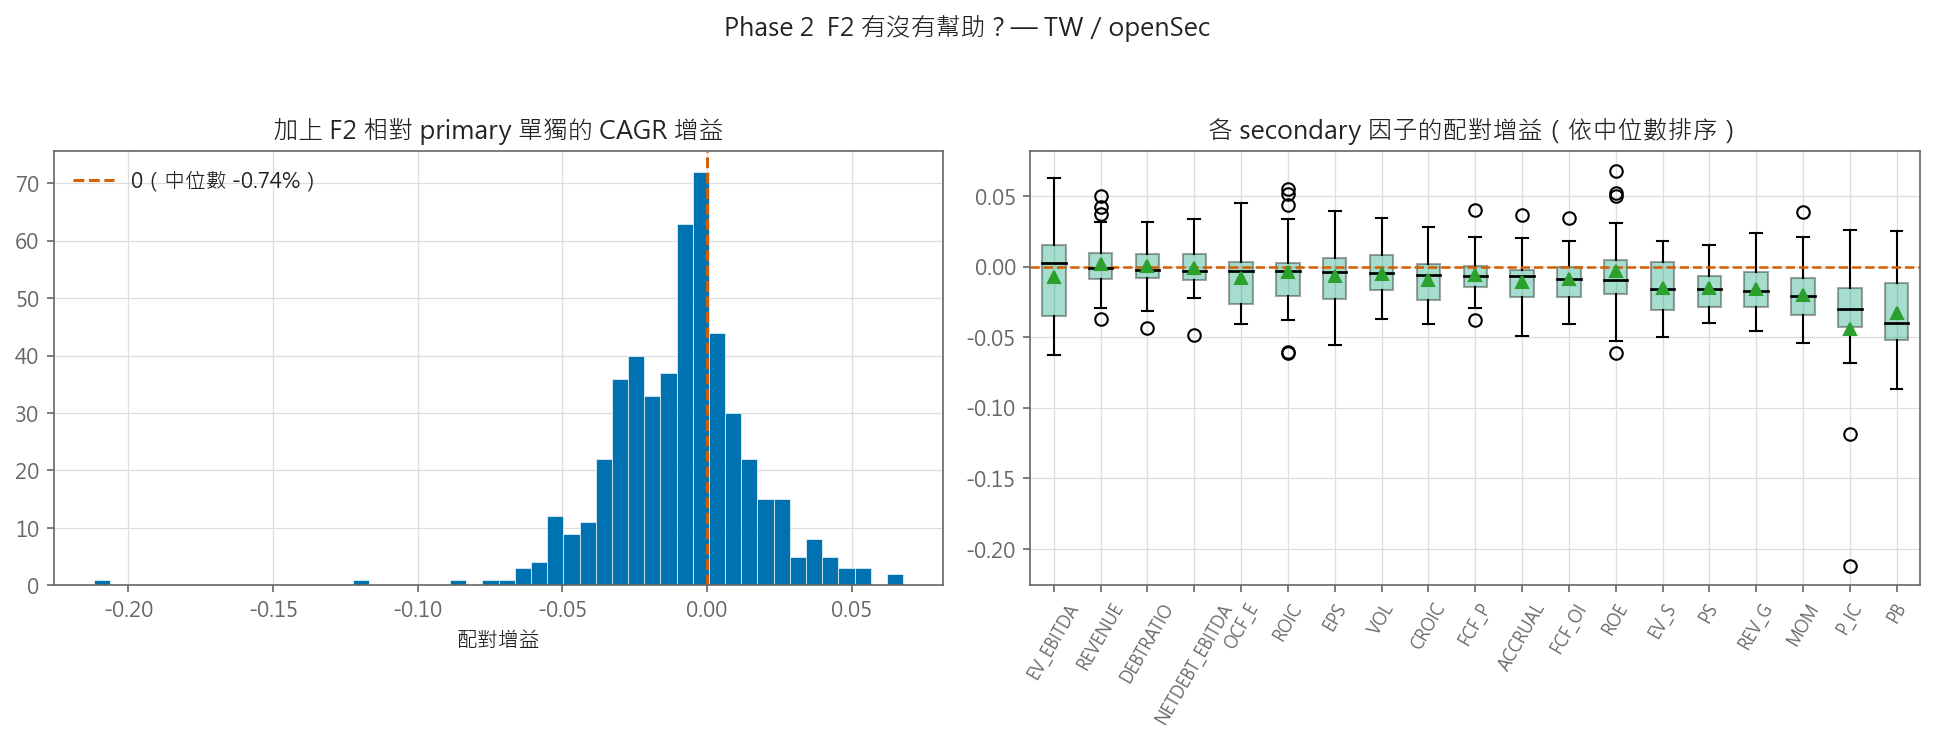

In [53]:
df = pd.read_csv(f'../_analysis_outputs_phase2/{MARKET}_L2_openSec{RSFX}_體質檢查表.csv')
display(df.head(10))
display(Image(f'../_analysis_outputs_phase2/{MARKET}_L2_openSec{RSFX}_pairing_gain.png'))


## 4. Phase 3：加入動態條件 C

在 Phase 2 通過配對的 F1×F2 策略上，疊加 20 種動態條件 C（衍生自 ROE/EPS/FCF_P，
例如「較上季升」「近N季最高」等時序條件），測試加入時間點篩選後績效是否提升。


In [54]:
%run phase3_conditions.py --market $MARKET --variant openSec --start $START_DATE --end $END_DATE --dry-run


[2026-08-28 00:12:48] === Phase 3 加入 C｜市場=TW｜期間 2000-01-01~2025-12-31 ===
[2026-08-28 00:12:48]     F 白名單（Phase 2 晉升）=218（單因子 10 / 配對 208）
[2026-08-28 00:12:48]     P1 條件=57｜C=20（+None=21 種 C 狀態）｜V=('v0',)
[2026-08-28 00:12:48]     預期共 4578 策略
[2026-08-28 00:12:48]     done  TW_L3_openSec_M
[2026-08-28 00:12:48] dry-run：不執行。


拿掉 `--dry-run` 真的執行（策略數再乘上20種C條件，是四個階段中最耗時的一段，
可能要數小時）：


In [55]:
%run phase3_conditions.py --market $MARKET --variant openSec --start $START_DATE --end $END_DATE


[2026-08-28 00:12:48] === Phase 3 加入 C｜市場=TW｜期間 2000-01-01~2025-12-31 ===
[2026-08-28 00:12:48]     F 白名單（Phase 2 晉升）=218（單因子 10 / 配對 208）
[2026-08-28 00:12:48]     P1 條件=57｜C=20（+None=21 種 C 狀態）｜V=('v0',)
[2026-08-28 00:12:48]     預期共 4578 策略
[2026-08-28 00:12:48]     done  TW_L3_openSec_M
[2026-08-28 00:12:48] 已完成，無待跑。


In [56]:
%run phase3_analyze.py --market $MARKET --variant openSec --start $START_DATE --end $END_DATE


基準 = 8.43%｜變體 = openSec｜期間 2000-01-01~2025-12-31｜持股數門檻 ≥ 10

讀入 4578 個策略｜F 組合 218 個｜C 狀態 21 種
依 Phase 2（openSec／universe）體質檢查表篩選：F 組合 218 → 218，策略 4578 個
計算平均每月持股數 …

===== A. 各 C 的價值（控制 F 後，相對同 F 的 None 基準）=====
 C編號                                C   C來源  增益中位數   增益平均 增益為正比例 CAGR中位數  持股數中位數   n
   4                 C4_ROE_DYN_qmax8   ROE +7.13% +7.20%  99.1%  21.84%    26.9 218
  11                C11_EPS_DYN_qmax8   EPS +4.67% +5.06%  96.3%  19.41%    31.5 218
   5                   C5_ROE_DYN_yoy   ROE +3.80% +3.99% 100.0%  18.35%    87.1 218
  12                  C12_EPS_DYN_yoy   EPS +3.48% +3.68% 100.0%  17.47%    92.9 218
   3                 C3_ROE_DYN_qmax4   ROE +3.43% +3.88%  96.8%  18.20%    49.1 218
   9                C9_EPS_DYN_riseq2   EPS +3.07% +3.04%  99.1%  16.93%    89.1 218
  10                C10_EPS_DYN_qmax4   EPS +2.92% +3.25%  96.3%  17.56%    53.0 218
   2                C2_ROE_DYN_riseq2   ROE +2.88% +2.99%  98.6%  17.03%    88.0 218
   7       C7_ROE_DYN_

看結果——加C後的候選策略表（前10筆，依CAGR排序），跟C條件增益圖：

,strategy,F組合,C,CAGR,None基準CAGR,C增益,max_drawdown,win_ratio,daily_sharpe,平均持股數
0,MOM_qb2of3__ACCRUAL_qb0of3__C4_ROE_DYN_qmax8__v0,MOM_qb2of3__ACCRUAL_qb0of3,C4_ROE_DYN_qmax8,0.337860,0.151721,0.186139,-0.696799,0.528270,14.25,25.223176
1,EV_S_qb0of3__REVENUE_qb0of3__C11_EPS_DYN_qmax8...,EV_S_qb0of3__REVENUE_qb0of3,C11_EPS_DYN_qmax8,0.329916,0.198987,0.130929,-0.518641,0.492243,11.28,11.261803
2,P_IC_qb0of3__REVENUE_qb0of3__C4_ROE_DYN_qmax8__v0,P_IC_qb0of3__REVENUE_qb0of3,C4_ROE_DYN_qmax8,0.329447,0.228413,0.101035,-0.658092,0.513393,14.67,11.072961
3,EV_S_qb0of3__REVENUE_qb0of3__C3_ROE_DYN_qmax4__v0,EV_S_qb0of3__REVENUE_qb0of3,C3_ROE_DYN_qmax4,0.325117,0.198987,0.126130,-0.398008,0.506310,11.02,20.706107
4,PS_qb0of3__REVENUE_qb0of3__C3_ROE_DYN_qmax4__v0,PS_qb0of3__REVENUE_qb0of3,C3_ROE_DYN_qmax4,0.319824,0.195898,0.123927,-0.539455,0.495108,11.23,16.717557
5,PS_qb0of3__REVENUE_qb0of3__C10_EPS_DYN_qmax4__v0,PS_qb0of3__REVENUE_qb0of3,C10_EPS_DYN_qmax4,0.318341,0.195898,0.122443,-0.509559,0.492381,11.27,17.541985
6,P_IC_qb0of3__REVENUE_qb0of3__C12_EPS_DYN_yoy__v0,P_IC_qb0of3__REVENUE_qb0of3,C12_EPS_DYN_yoy,0.312816,0.228413,0.084404,-0.528444,0.503781,13.24,48.120000
7,P_IC_qb0of3__REVENUE_qb0of3__C5_ROE_DYN_yoy__v0,P_IC_qb0of3__REVENUE_qb0of3,C5_ROE_DYN_yoy,0.307773,0.228413,0.079360,-0.543880,0.514655,12.87,45.672000
8,PS_qb0of3__REVENUE_qb0of3__C12_EPS_DYN_yoy__v0,PS_qb0of3__REVENUE_qb0of3,C12_EPS_DYN_yoy,0.302878,0.195898,0.106980,-0.427824,0.494860,11.82,29.496000
9,P_IC_qb0of3__VOL_qb2of3__C4_ROE_DYN_qmax8__v0,P_IC_qb0of3__VOL_qb2of3,C4_ROE_DYN_qmax8,0.302774,0.212954,0.089821,-0.655088,0.509756,12.78,20.111588


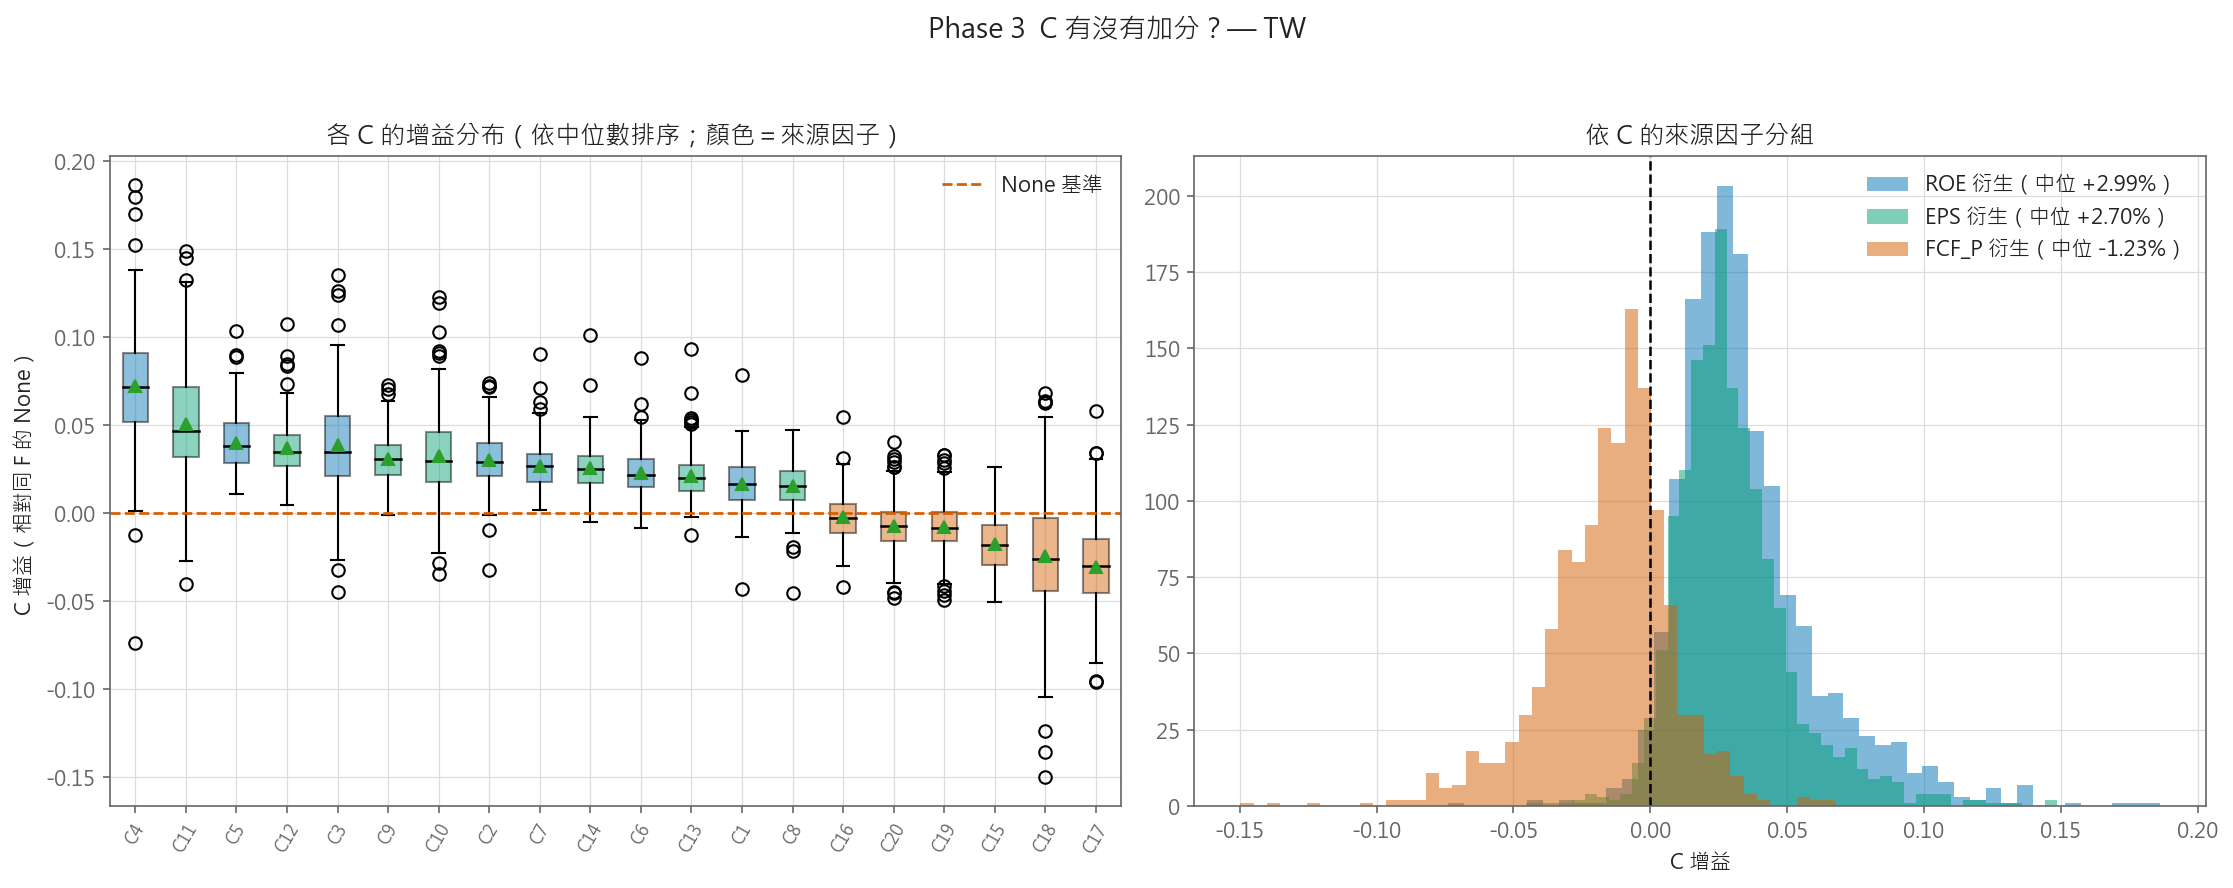

In [57]:
df = pd.read_csv(f'../_analysis_outputs_phase3/{MARKET}_L3_openSec{RSFX}_candidate_strategies.csv')
display(df.sort_values('CAGR', ascending=False).head(10))
display(Image(f'../_analysis_outputs_phase3/{MARKET}_L3_openSec{RSFX}_C_gain.png'))


**圖4-16**：控制 F 之後，各 C 條件的 CAGR 折線圖（左：12個單因子組合，右：全部203個F組合）。
直看＝在這個F區間下哪個C最好；橫看＝這個C是不是穩定有效：


In [58]:
%run phase3_fig416.py --market $MARKET --variant openSec --start $START_DATE --end $END_DATE


輸出：D:\git\stock_factor_lab\_analysis_outputs_phase3\TW_L3_openSec_fig4-16_controlled_C_lines.png

增益中位數 前3： C4_ROE_DYN_qmax8, C11_EPS_DYN_qmax8, C5_ROE_DYN_yoy
增益中位數 後3： C15_FCF_P_DYN_riseq1, C18_FCF_P_DYN_qmax8, C17_FCF_P_DYN_qmax4


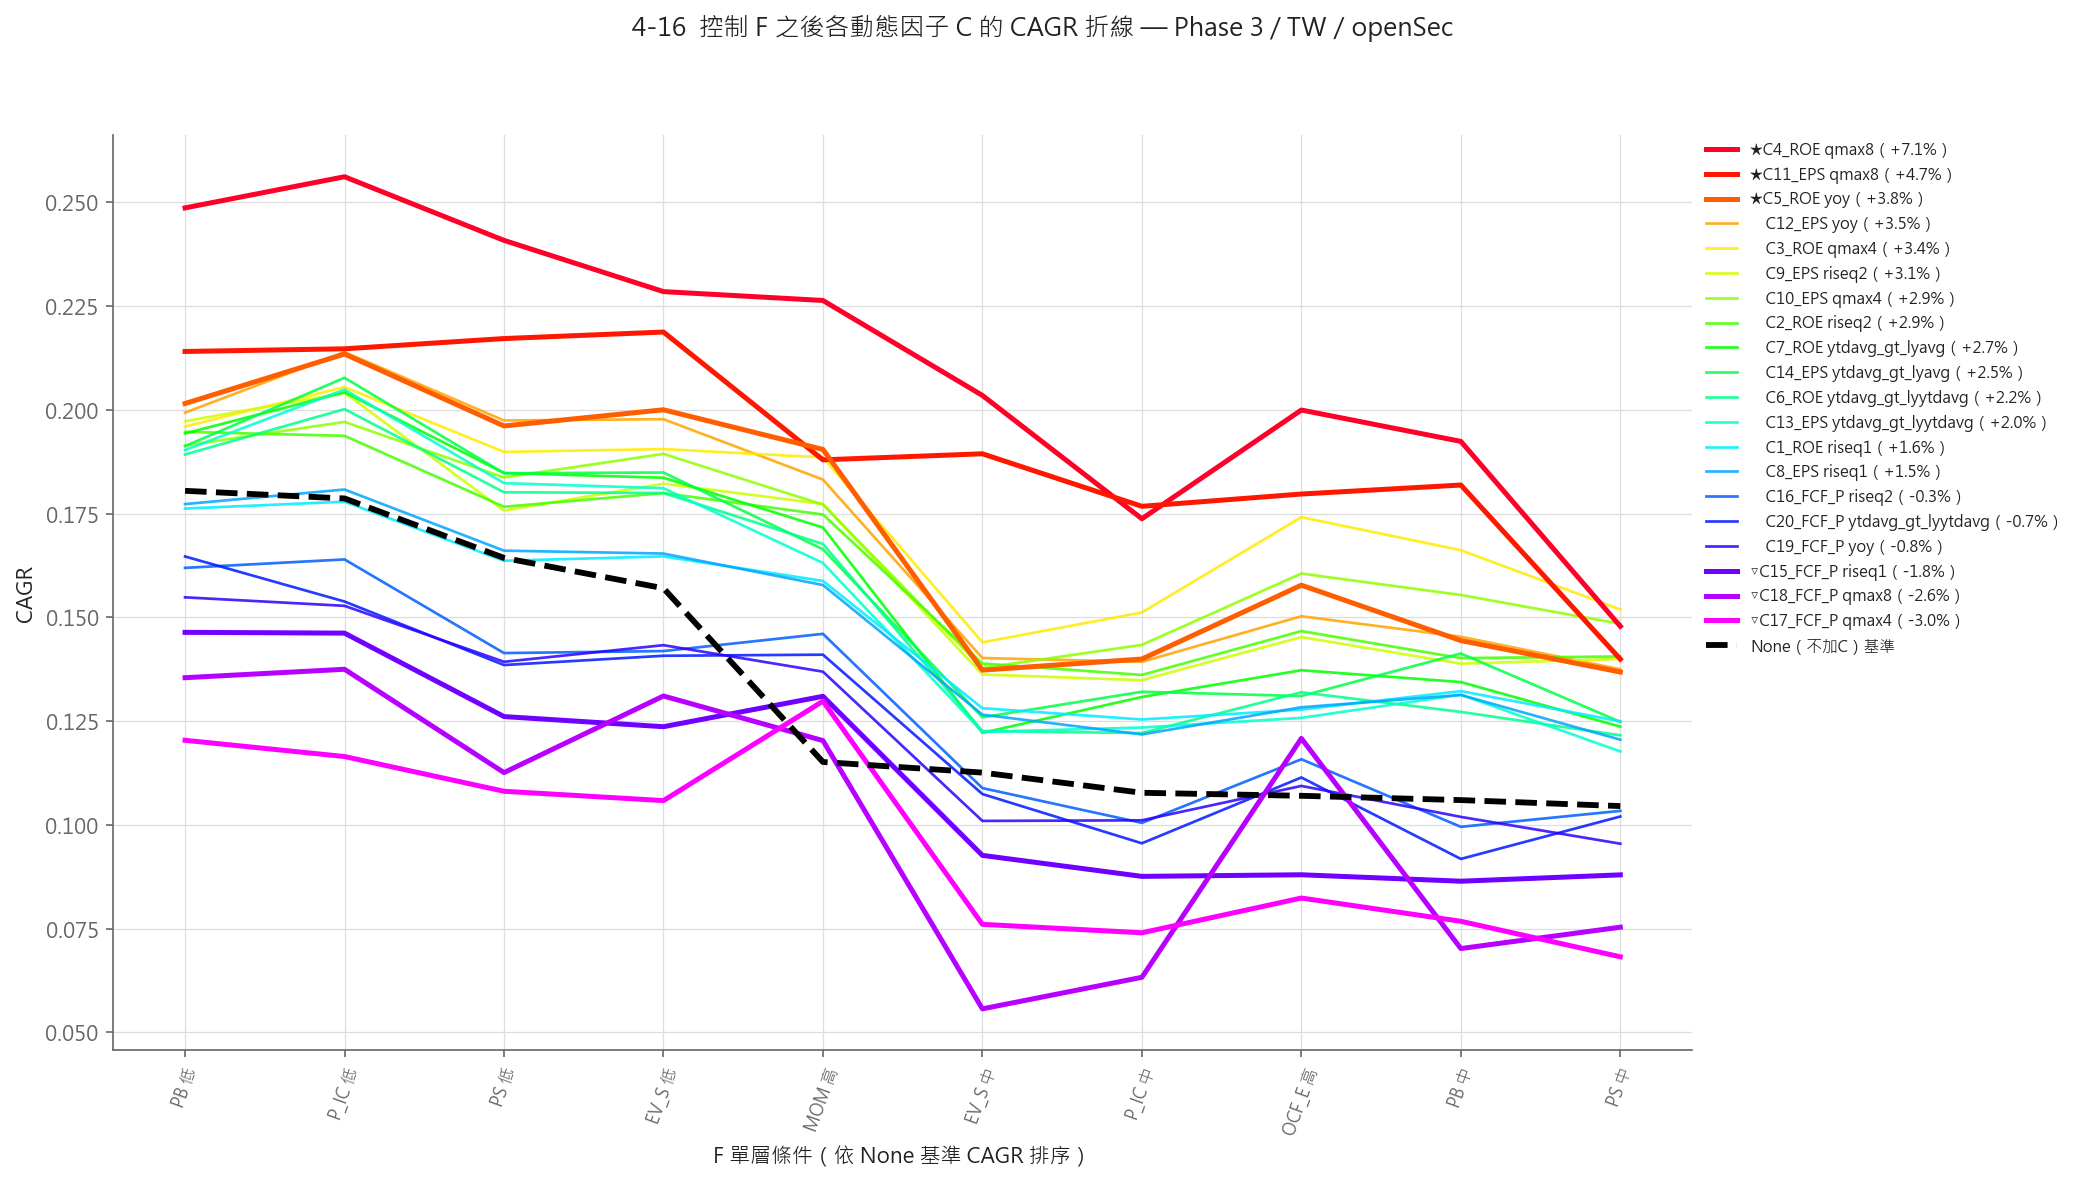

In [59]:
display(Image(f'../_analysis_outputs_phase3/{MARKET}_L3_openSec_fig4-16{RSFX}_controlled_C_lines.png'))


## 5. Phase 4：加入估值濾網 V

疊加 PE 相對估值濾網（v0=不濾、v1=濾），測試估值維度是否能再提升績效。
FCV 框架（F體質因子 × C動態條件 × V估值濾網）的最後一個維度：


In [60]:
%run phase4_valuation.py --market $MARKET --variant openSec --start $START_DATE --end $END_DATE --dry-run


[2026-08-28 00:18:35] === Phase 4 加入 V｜市場=TW｜期間 2000-01-01~2025-12-31 ===
[2026-08-28 00:18:35]     F 白名單=218｜C 狀態=21｜V=('v1',)（v0 沿用 Phase 3）
[2026-08-28 00:18:35]     預期共 4578 策略
[2026-08-28 00:18:35]     done  TW_L4_openSec_M
[2026-08-28 00:18:35] dry-run：不執行。


拿掉 `--dry-run` 真的執行：


In [61]:
%run phase4_valuation.py --market $MARKET --variant openSec --start $START_DATE --end $END_DATE


[2026-08-28 00:18:35] === Phase 4 加入 V｜市場=TW｜期間 2000-01-01~2025-12-31 ===
[2026-08-28 00:18:35]     F 白名單=218｜C 狀態=21｜V=('v1',)（v0 沿用 Phase 3）
[2026-08-28 00:18:35]     預期共 4578 策略
[2026-08-28 00:18:35]     done  TW_L4_openSec_M
[2026-08-28 00:18:35] 已完成，無待跑。


In [62]:
%run phase4_analyze.py --market $MARKET --variant openSec --start $START_DATE --end $END_DATE


基準 = 8.43%｜變體 = openSec｜期間 2000-01-01~2025-12-31

v0（Phase 3）4578 個｜v1（Phase 4）4577 個
依 Phase 2（openSec／universe）篩後：F 組合 218 個
成功配對 4577 組 v0/v1

計算 v1 的平均持股數 …
===== A. 加 V1 的整體效果 =====
  ΔCAGR 中位數 -1.79%｜平均 -2.24%｜為正比例 29.6%
  ΔMDD  中位數 -1.89%｜為正(風險下降)比例 39.6%
  持股數：v0 中位 77.5 → v1 中位 12.6

===== B. ΔCAGR × ΔMDD 四象限 =====
  ① 報酬升 風險降（雙贏）              712   15.6%
  ② 報酬升 風險升                  642   14.0%
  ③ 報酬降 風險降（換取穩定）           1101   24.1%
  ④ 報酬降 風險升（雙輸）             2122   46.4%

===== C. 依 C 分組：加 V1 的 ΔCAGR（前5／後5）=====
                                 dCAGR中位  dMDD中位    n
C_v0                                                 
C10_EPS_DYN_qmax4                 +0.28%  +4.52%  218
C7_ROE_DYN_ytdavg_gt_lyavg        -0.47%  -4.93%  218
C3_ROE_DYN_qmax4                  -0.69%  +0.47%  218
C20_FCF_P_DYN_ytdavg_gt_lyytdavg  -0.93%  -1.67%  218
C14_EPS_DYN_ytdavg_gt_lyavg       -1.05%  -1.27%  218
  …
                     dCAGR中位  dMDD中位    n
C_v0                                     
C1

看結果——最終候選策略表（前10筆，依CAGR排序），跟V濾網效果圖：

,strategy,F組合,C,CAGR,max_drawdown,win_ratio,持股數,V
0,MOM_qb2of3__ACCRUAL_qb0of3__C4_ROE_DYN_qmax8__v0,MOM_qb2of3__ACCRUAL_qb0of3,C4_ROE_DYN_qmax8,0.337860,-0.696799,0.528270,25.223176,v0
1,EV_S_qb0of3__REVENUE_qb0of3__C11_EPS_DYN_qmax8...,EV_S_qb0of3__REVENUE_qb0of3,C11_EPS_DYN_qmax8,0.329916,-0.518641,0.492243,11.261803,v0
2,P_IC_qb0of3__REVENUE_qb0of3__C4_ROE_DYN_qmax8__v0,P_IC_qb0of3__REVENUE_qb0of3,C4_ROE_DYN_qmax8,0.329447,-0.658092,0.513393,11.072961,v0
3,EV_S_qb0of3__REVENUE_qb0of3__C3_ROE_DYN_qmax4__v0,EV_S_qb0of3__REVENUE_qb0of3,C3_ROE_DYN_qmax4,0.325117,-0.398008,0.506310,20.706107,v0
4,PS_qb0of3__REVENUE_qb0of3__C3_ROE_DYN_qmax4__v0,PS_qb0of3__REVENUE_qb0of3,C3_ROE_DYN_qmax4,0.319824,-0.539455,0.495108,16.717557,v0
5,PS_qb0of3__REVENUE_qb0of3__C10_EPS_DYN_qmax4__v0,PS_qb0of3__REVENUE_qb0of3,C10_EPS_DYN_qmax4,0.318341,-0.509559,0.492381,17.541985,v0
6,P_IC_qb0of3__REVENUE_qb0of3__C12_EPS_DYN_yoy__v0,P_IC_qb0of3__REVENUE_qb0of3,C12_EPS_DYN_yoy,0.312816,-0.528444,0.503781,48.120000,v0
7,P_IC_qb0of3__REVENUE_qb0of3__C5_ROE_DYN_yoy__v0,P_IC_qb0of3__REVENUE_qb0of3,C5_ROE_DYN_yoy,0.307773,-0.543880,0.514655,45.672000,v0
8,PS_qb0of3__REVENUE_qb0of3__C12_EPS_DYN_yoy__v0,PS_qb0of3__REVENUE_qb0of3,C12_EPS_DYN_yoy,0.302878,-0.427824,0.494860,29.496000,v0
9,P_IC_qb0of3__VOL_qb2of3__C4_ROE_DYN_qmax8__v0,P_IC_qb0of3__VOL_qb2of3,C4_ROE_DYN_qmax8,0.302774,-0.655088,0.509756,20.111588,v0


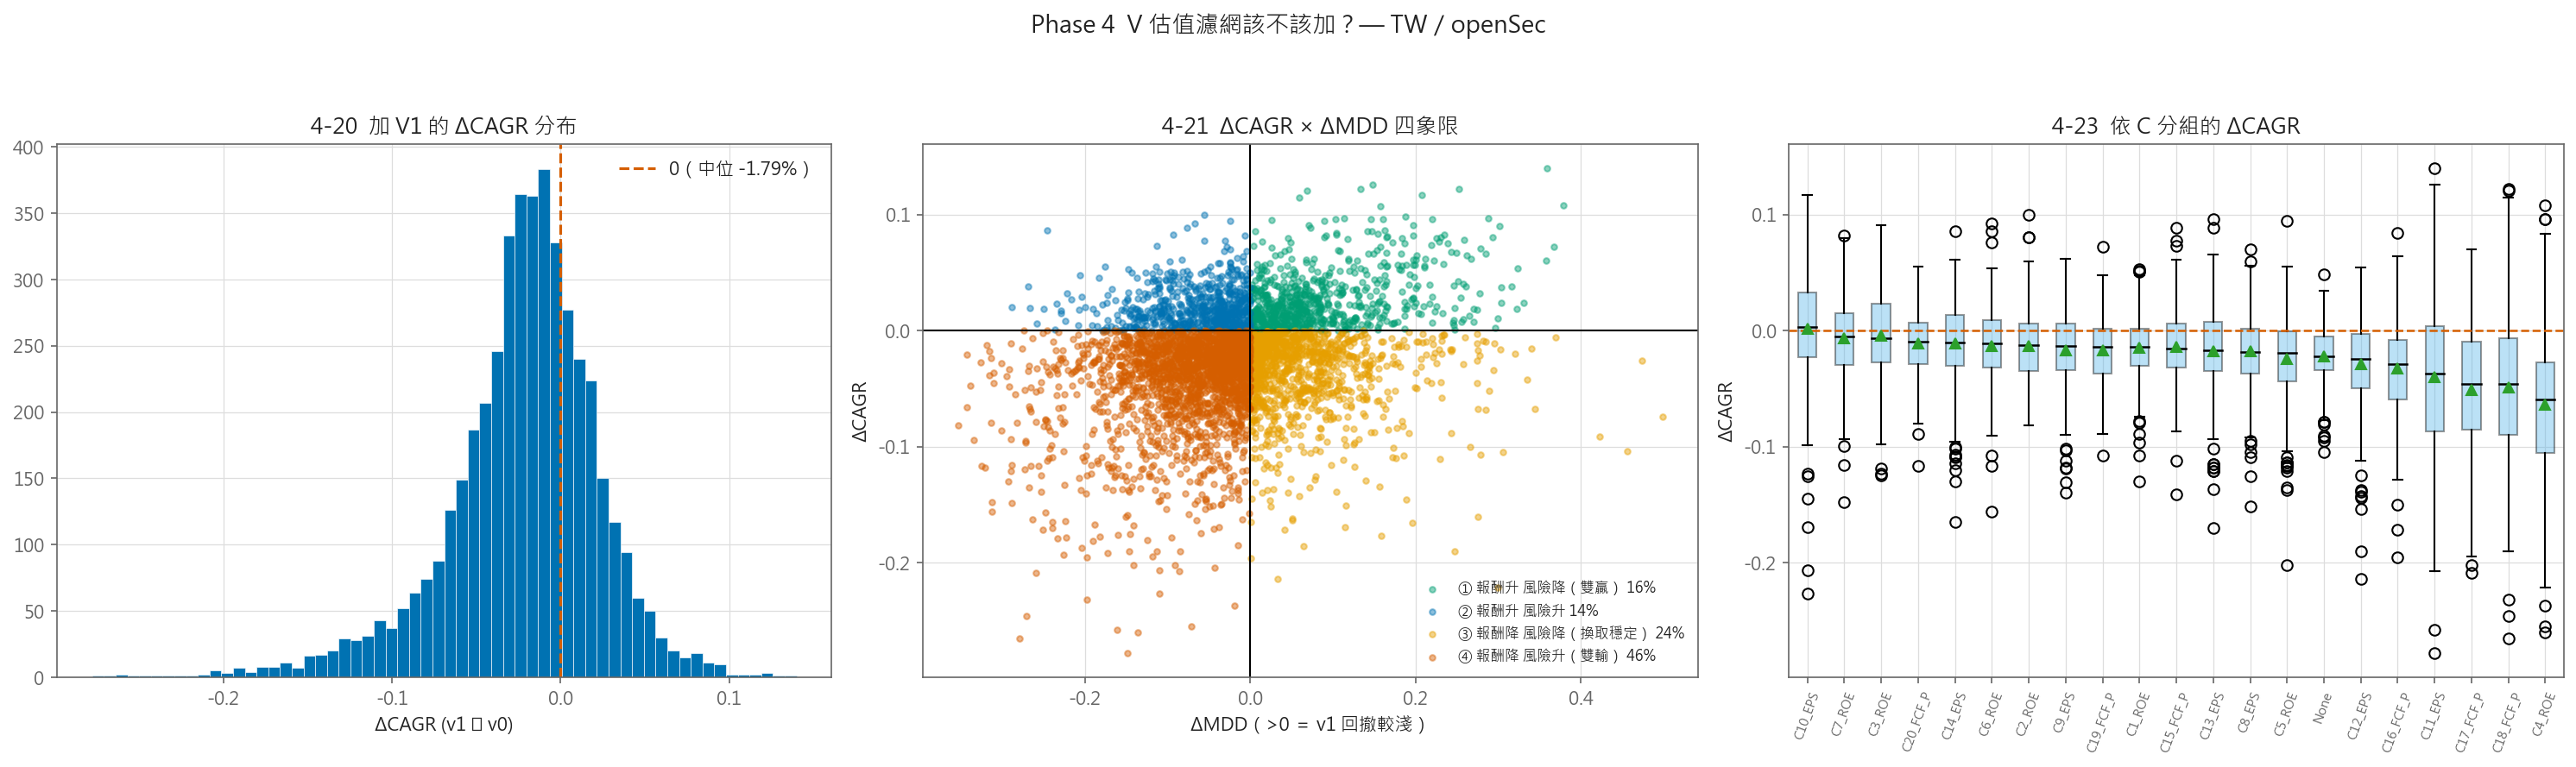

In [63]:
df = pd.read_csv(f'../_analysis_outputs_phase4/{MARKET}_L4_openSec{RSFX}_final_candidates.csv')
display(df.sort_values('CAGR', ascending=False).head(10))
display(Image(f'../_analysis_outputs_phase4/{MARKET}_L4_openSec{RSFX}_V_effect.png'))


## 6. 完整圖鑑（18張圖）

`build_atlas.py` 把 Phase 3（v0）與 Phase 4（v1）的結果合併，產出一組共18張圖的完整圖鑑，
涵蓋策略貢獻分解、F1×F2熱力圖、C條件分布、V0/V1比較等面向。需要 Phase 3、Phase 4 都已執行完：


In [64]:
%run build_atlas.py --market $MARKET --variant openSec --start $START_DATE --end $END_DATE


=== 第四章圖鑑｜TW／openSec｜期間 2000-01-01~2025-12-31 ===
>> 合併 TW_L3_openSec_M（4578 個 v0）+ TW_L4_openSec_M（4577 個 v1）= 9155 個策略
>> [TW_ATLAS_openSec_M] 讀 stats.parquet …
   策略數=9155｜pair=8735｜single=420｜因子=['EV_S', 'MOM', 'OCF_E', 'PB', 'PS', 'P_IC']
>> 4-2 Top10 熱力圖
>> 4-3/4-4 代表策略解剖（EV_S_qb0of3__REVENUE_qb0of3__C3_ROE_DYN_qmax4__v1）
>> 4-12 單層F CAGR盒鬚圖（依中位數排序）
>> 4-13 F1×F2 統一熱力圖
>> 4-15 不控制F的C盒鬚圖（反例）
>> 4-16 主入口：統一F軸的C折線
>> 4-17 各C的F1×F2熱力圖小圖組
>> V0/V1 配對 → 4-20/4-21/4-22/4-23
>> 4-18/4-24 自動選子樹深挖
>> 4-5~4-10 可信度（逐策略讀 trades.parquet，較耗時）
   [credibility:top25%] 掃 2289 個策略的 trades.parquet …
      1000/2289（130s）
      2000/2289（238s）
   [credibility:top25%] 完成，269s
   [credibility:top50%] 掃 4578 個策略的 trades.parquet …
      1000/4578（77s）
      2000/4578（161s）
      3000/4578（250s）
      4000/4578（336s）
   [credibility:top50%] 完成，386s
   → credibility_metrics_top50.parquet 已存

>> [TW_ATLAS_openSec_M] 完成，圖表 18 張，總耗時 665s → D:\git\stock_factor_lab\_analysis_outputs\TW_ATLAS_openSec_M\figures
 

4-10_effective_n.png


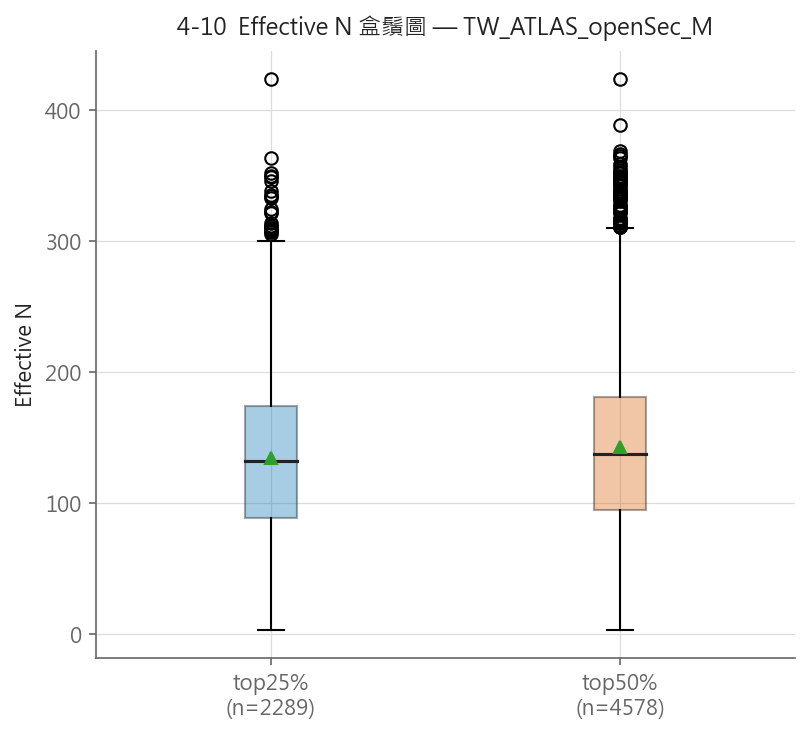

4-12_factor_boxplot.png


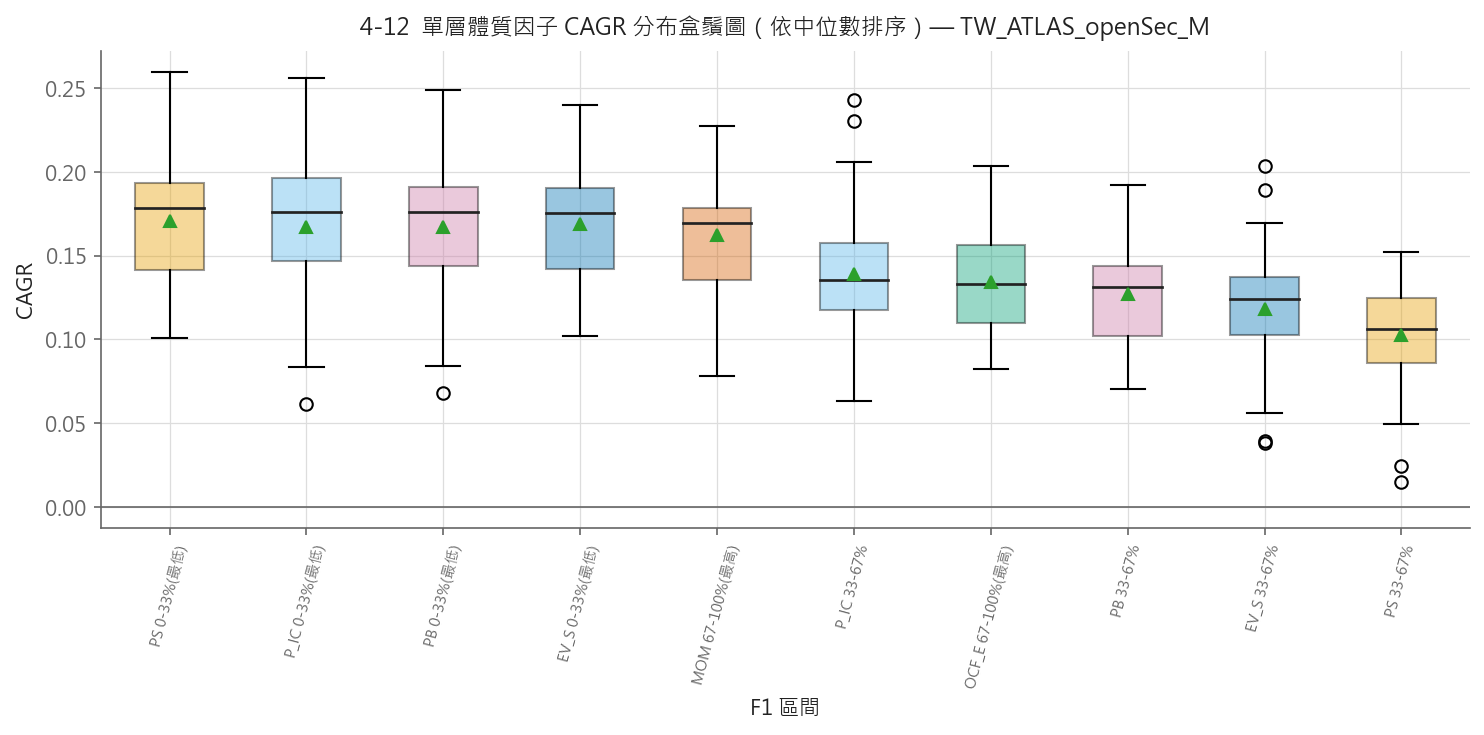

4-13_F1xF2_heatmap.png


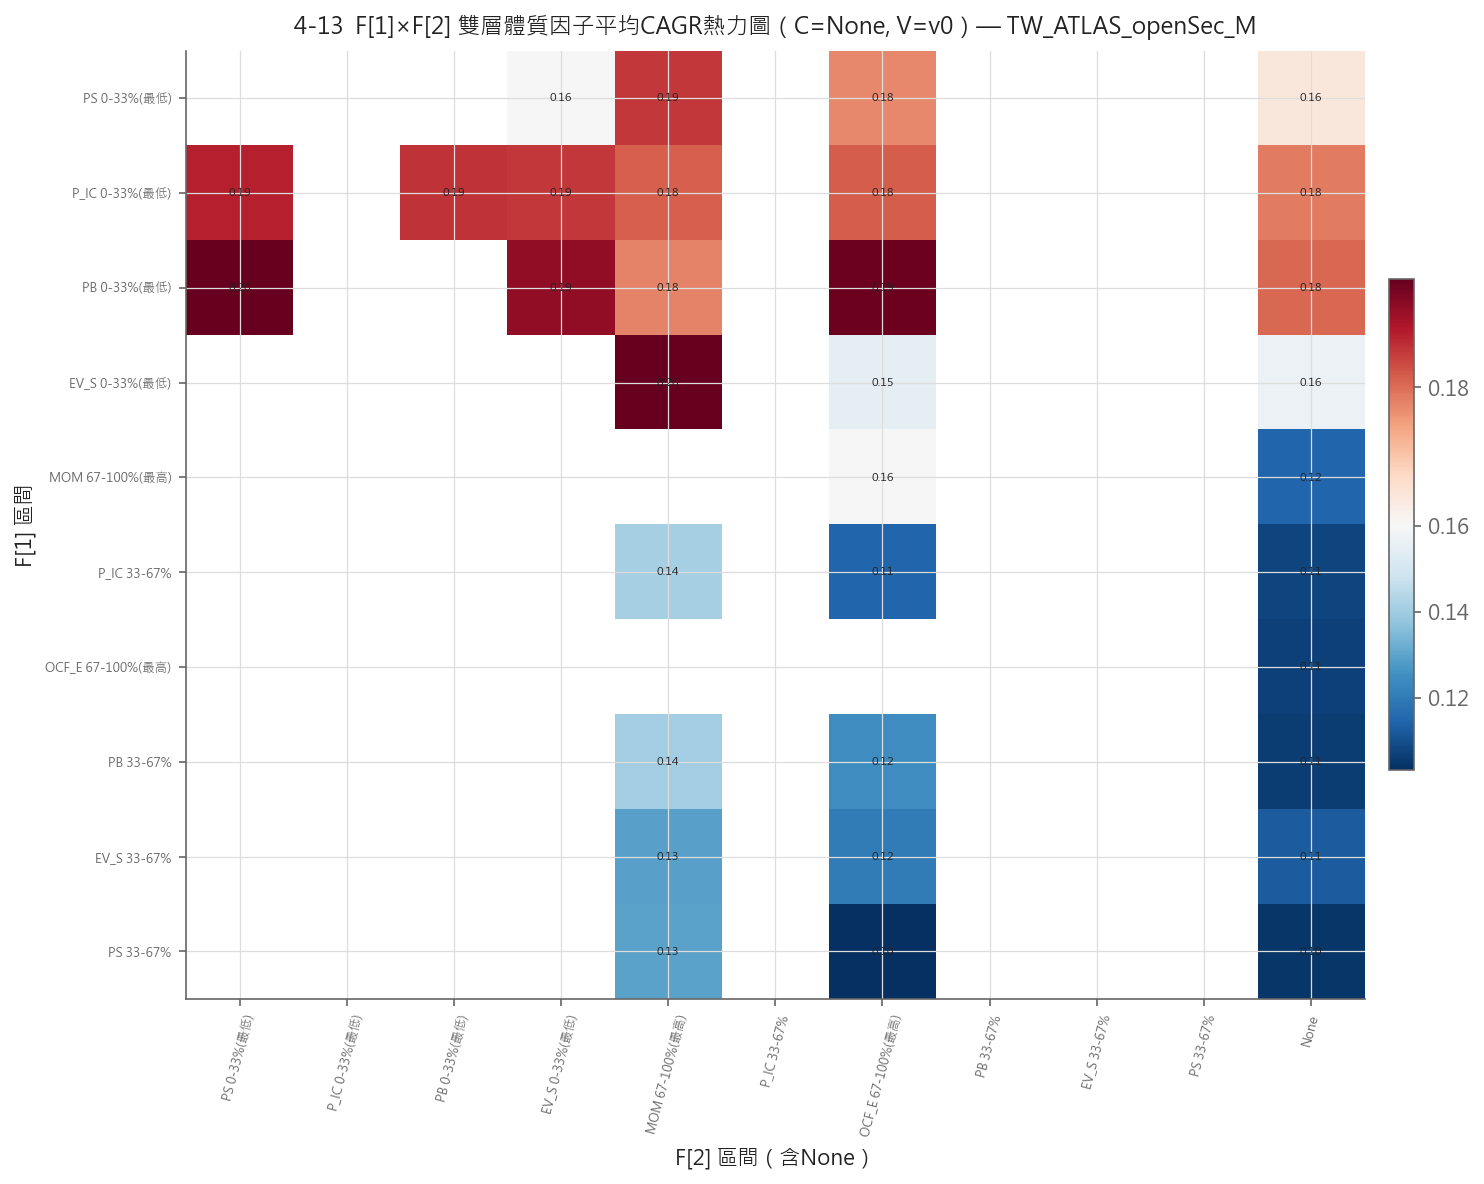

4-15_uncontrolled_C.png


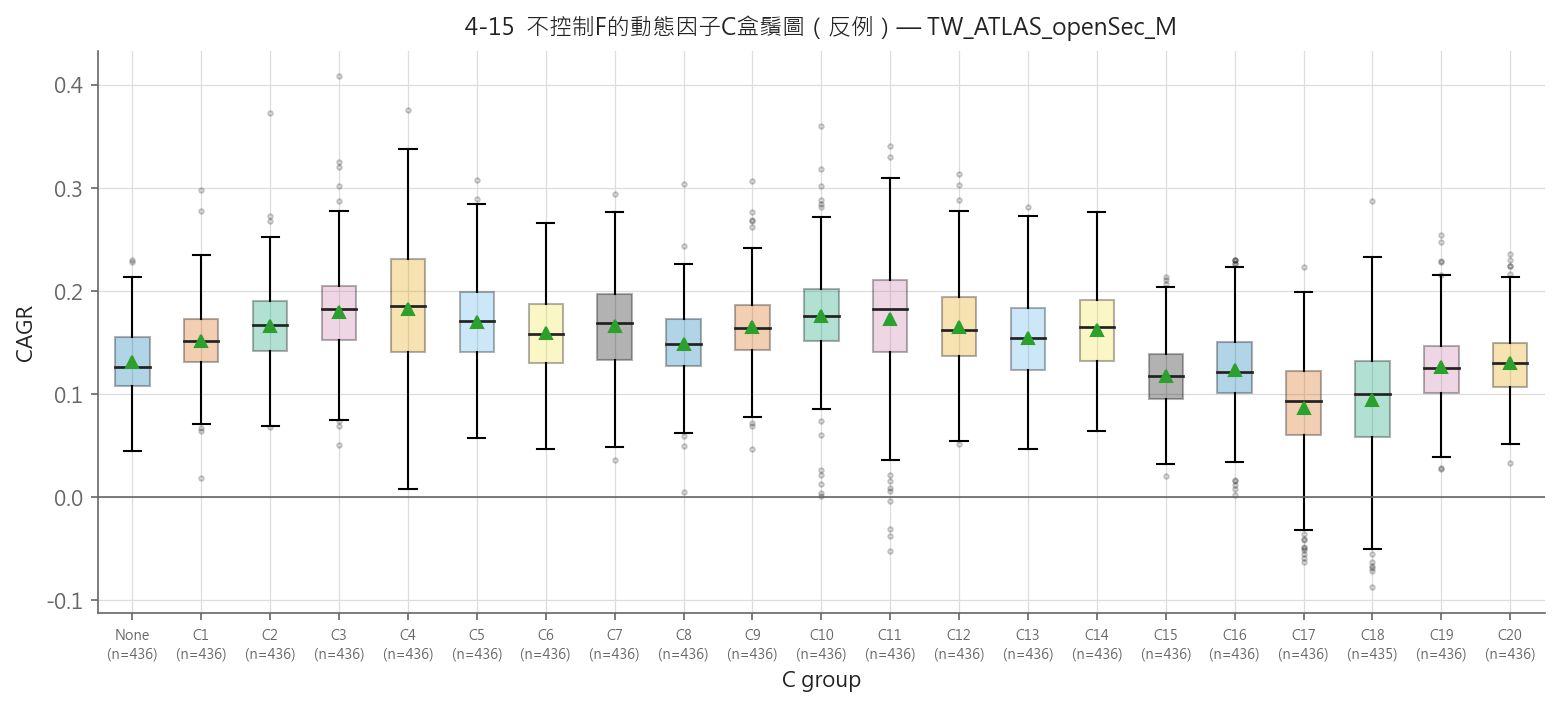

4-16_controlled_C_lines.png


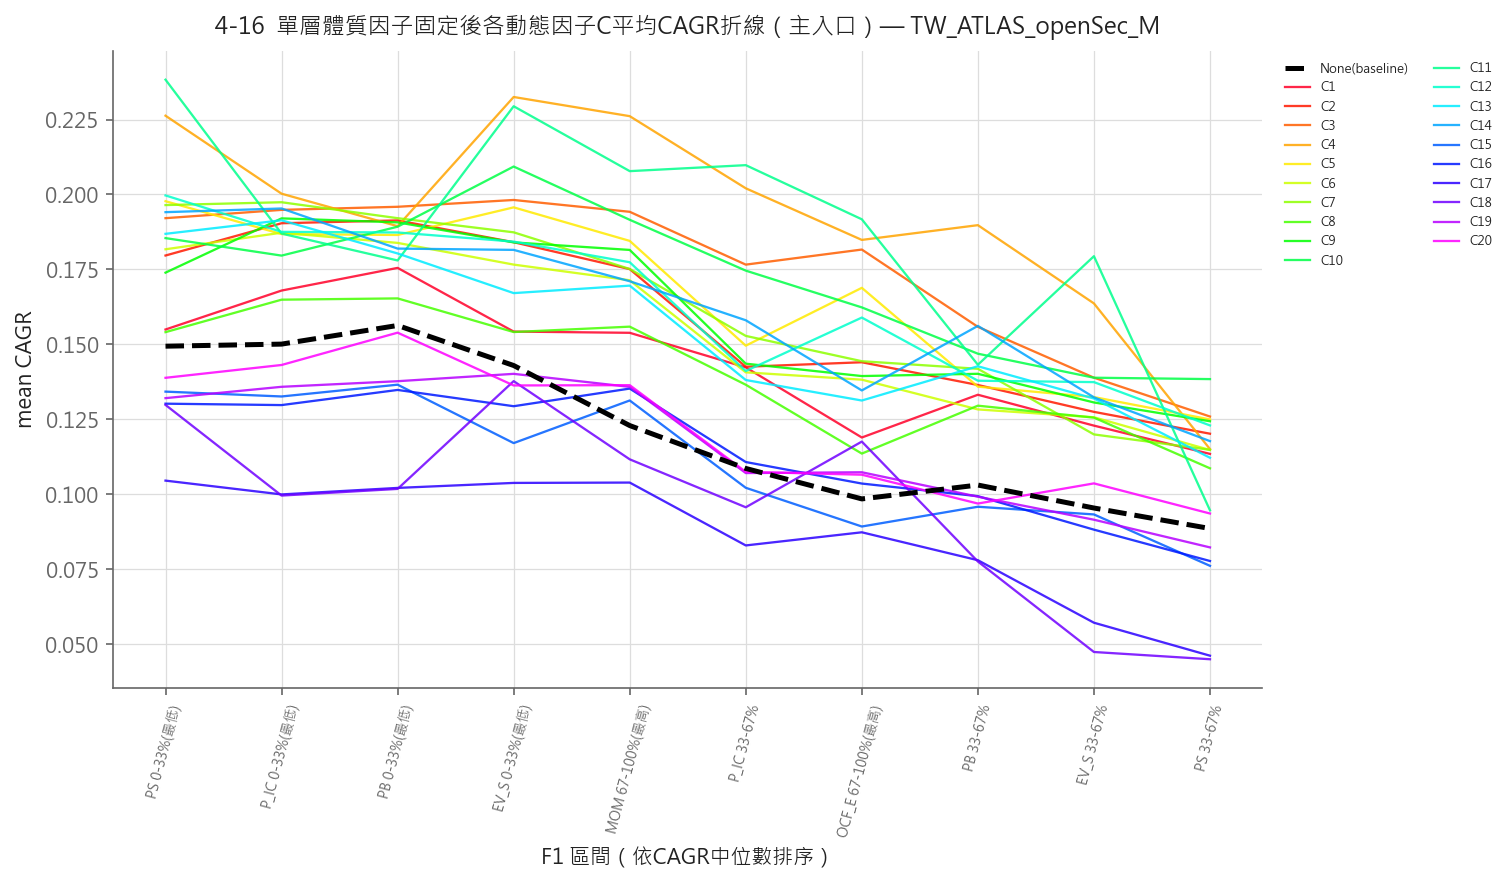

4-17_F1xF2_by_C_grid.png


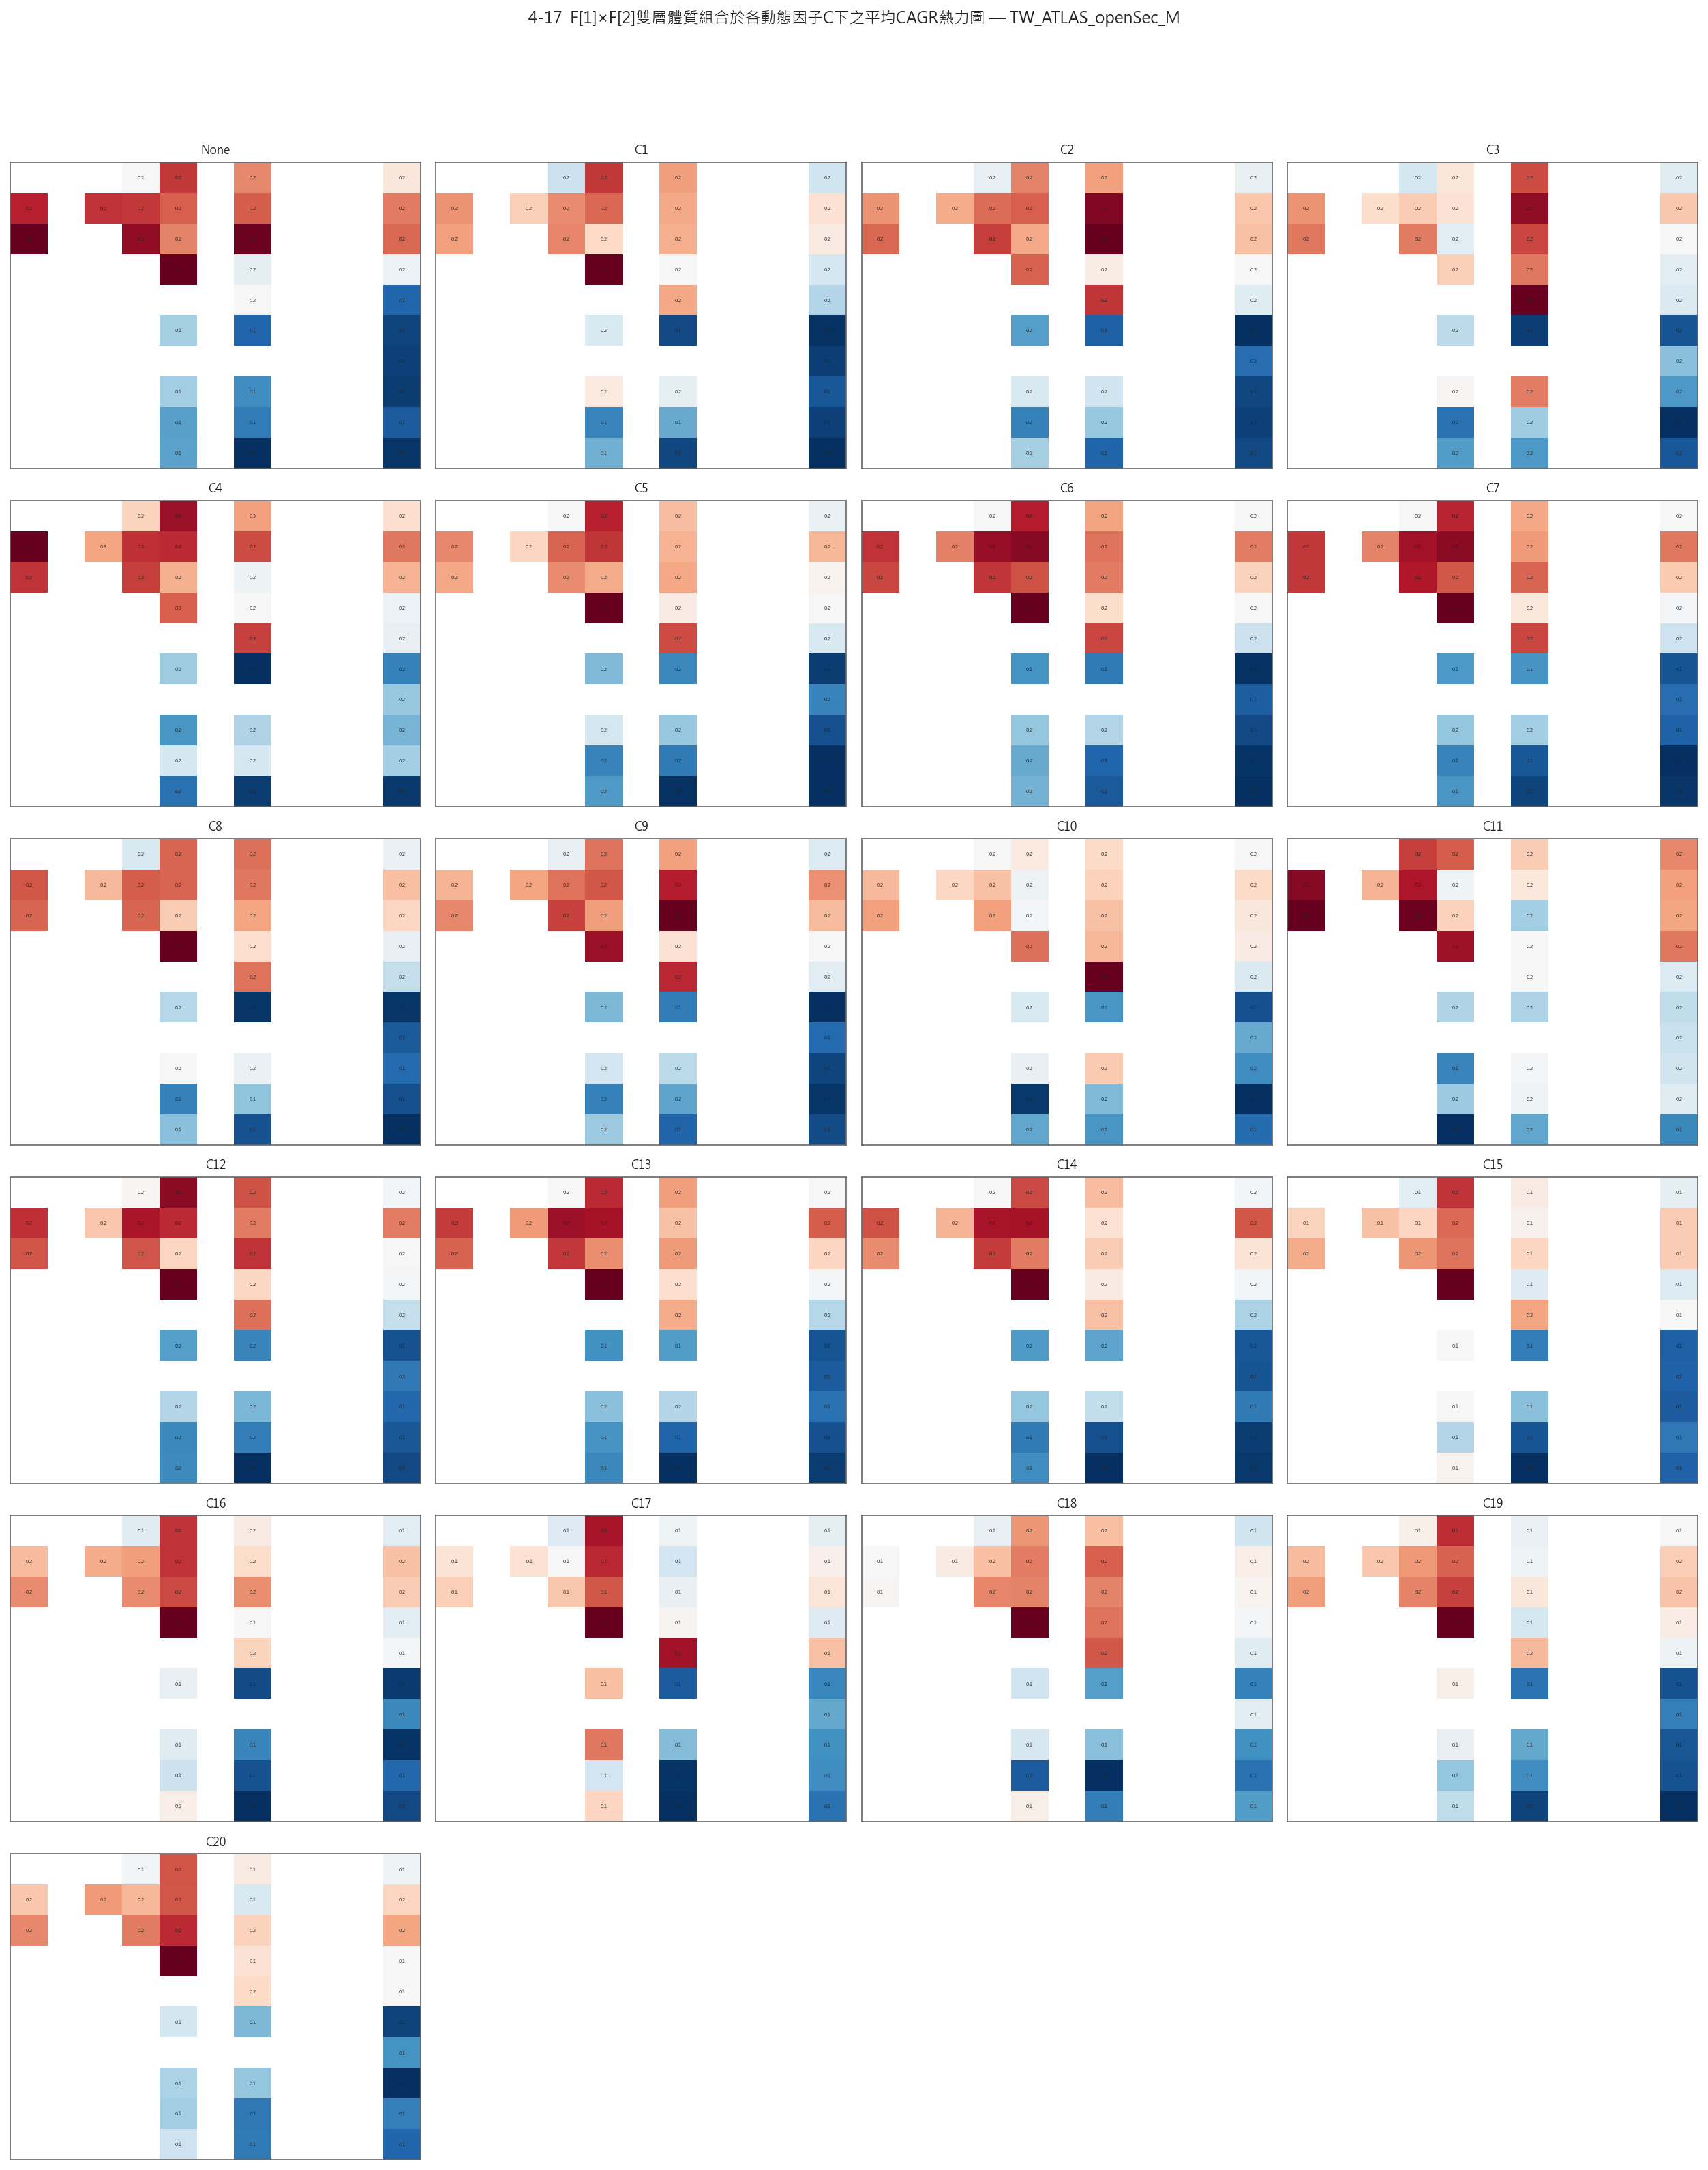

4-18_subtree_C_distribution.png


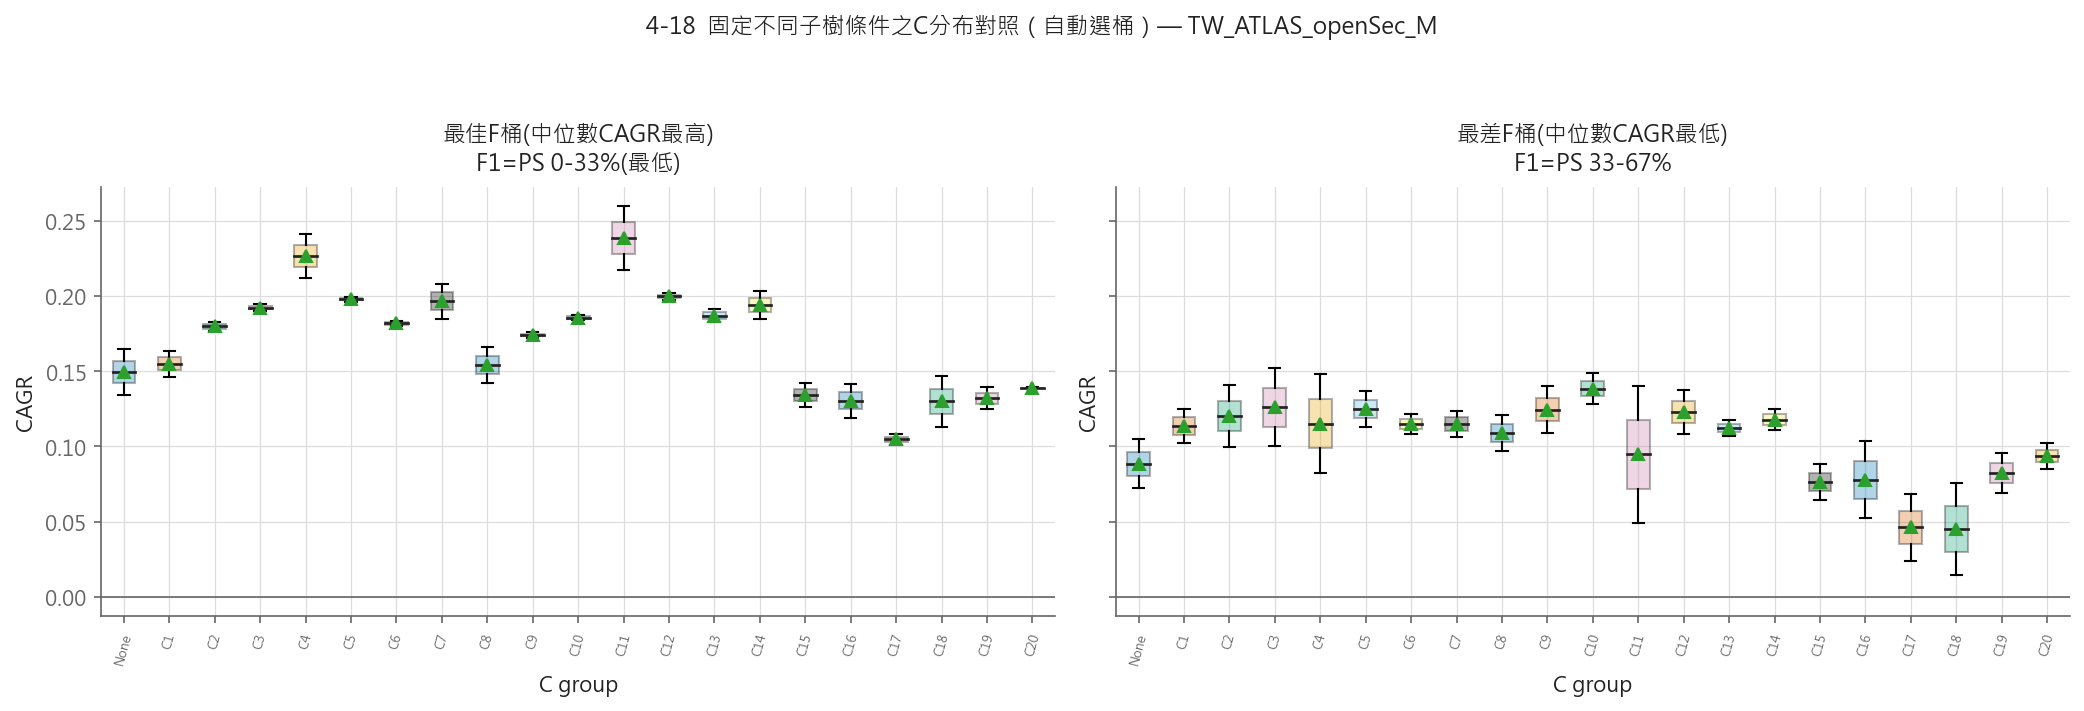

4-20_dCAGR_distribution.png


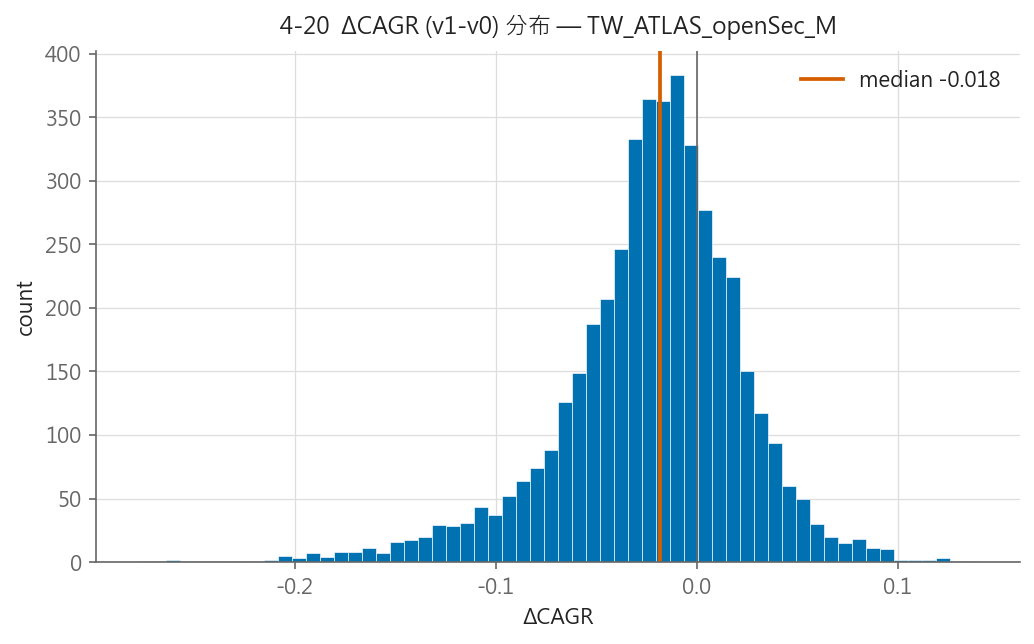

4-21_dCAGR_dMDD_quadrant.png


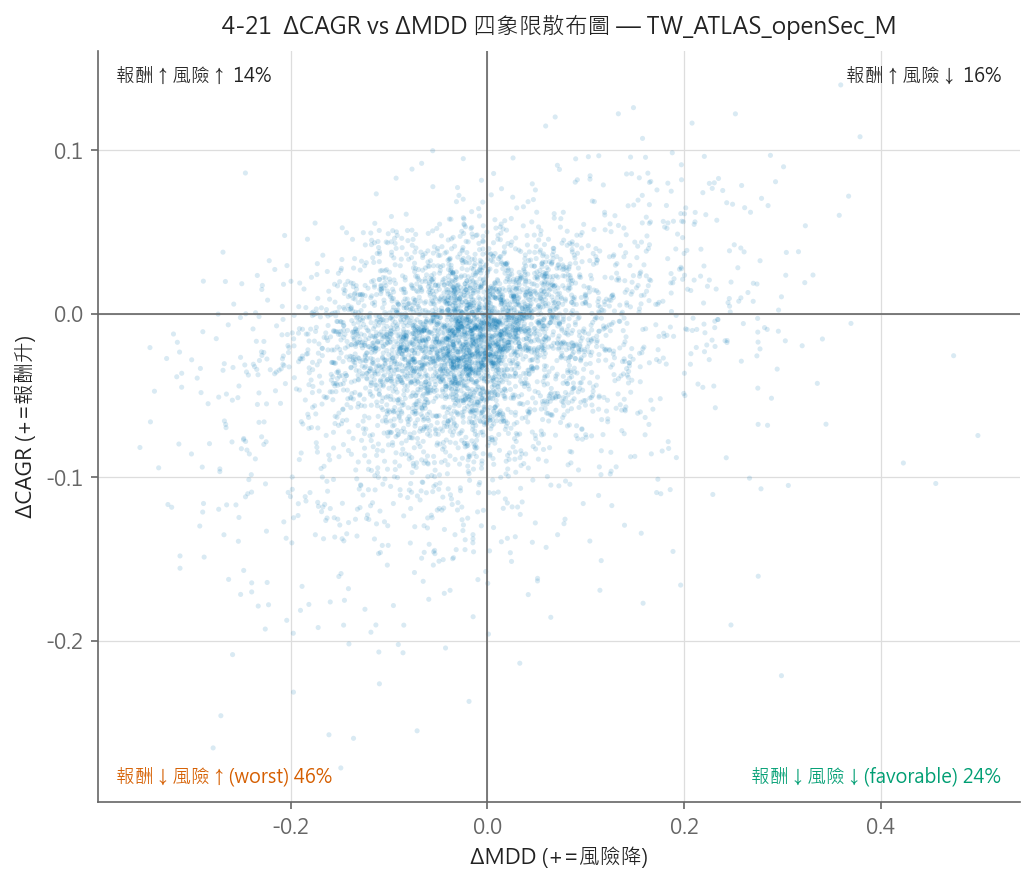

4-22_V0_V1_by_F_bucket.png


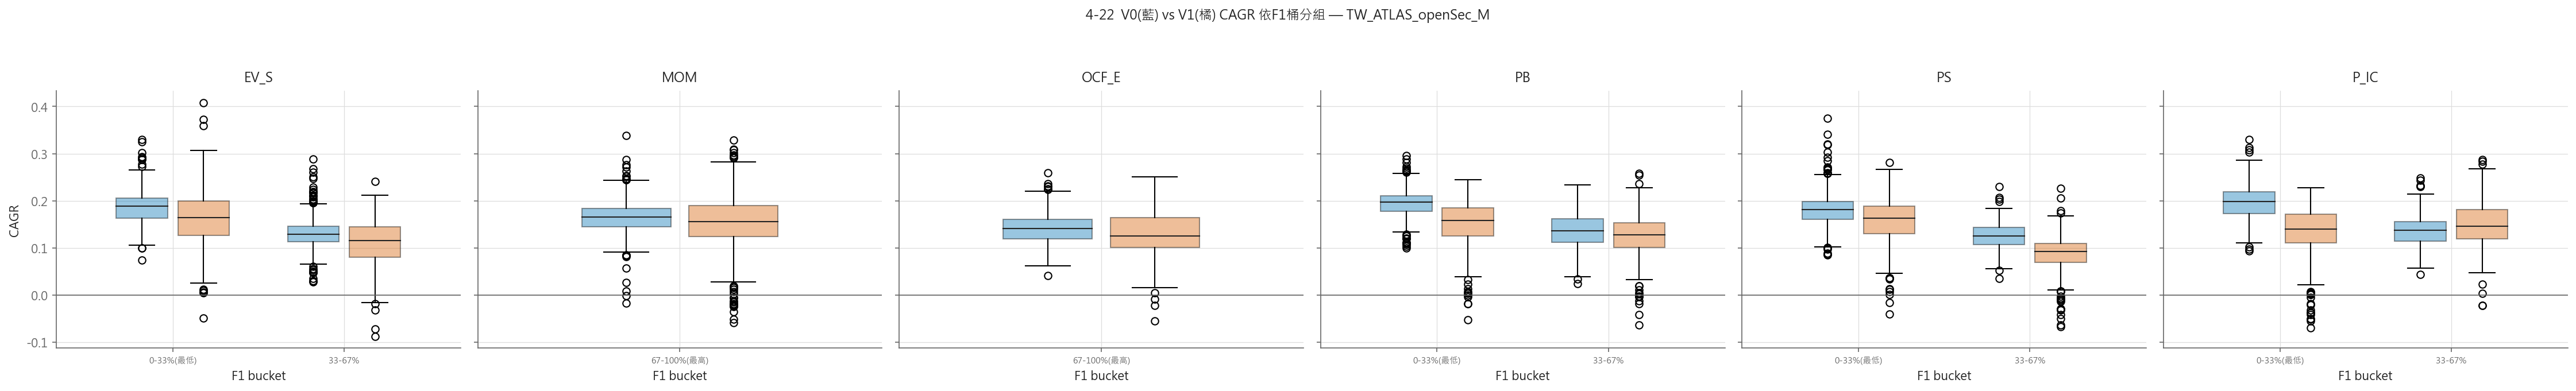

4-23_V0_V1_by_C.png


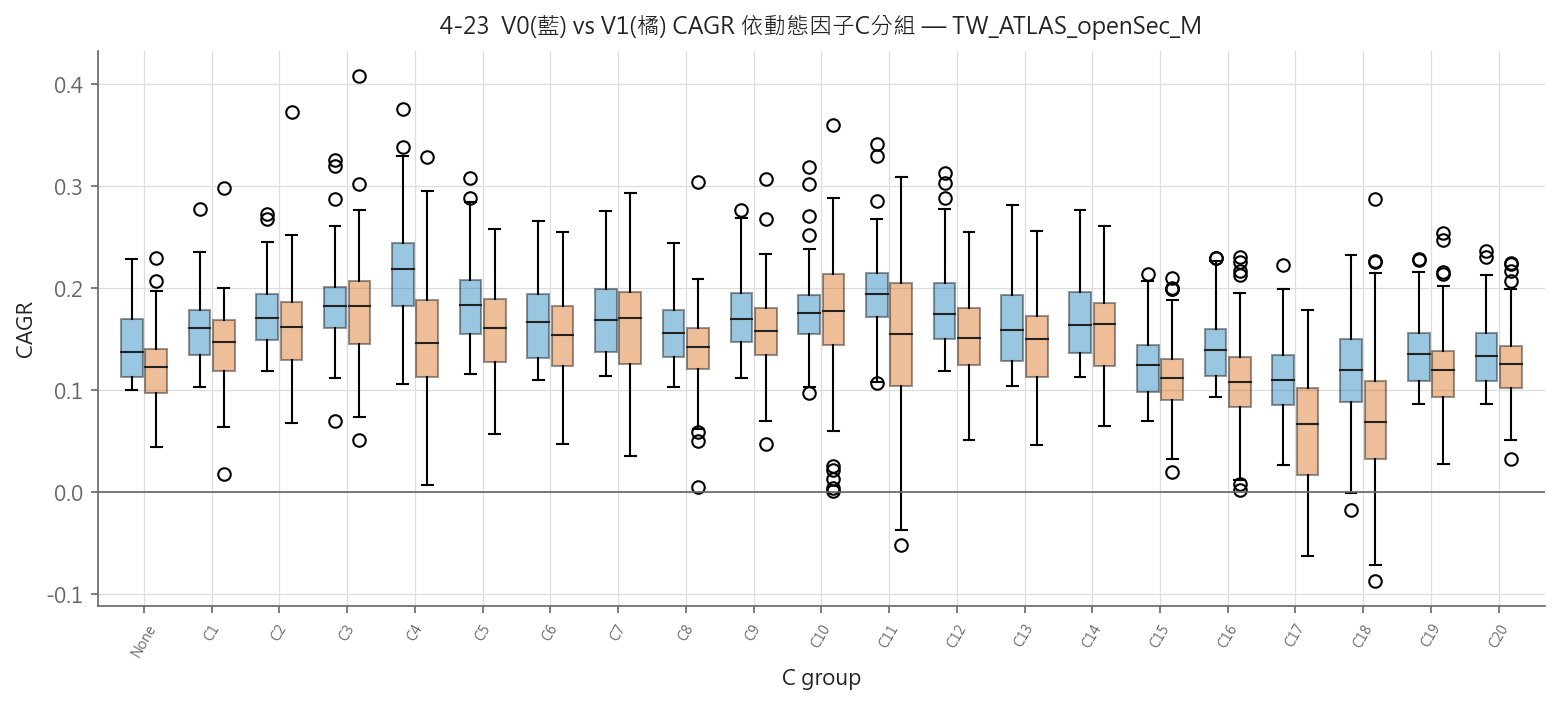

4-24_subtree_V0_V1_by_C.png


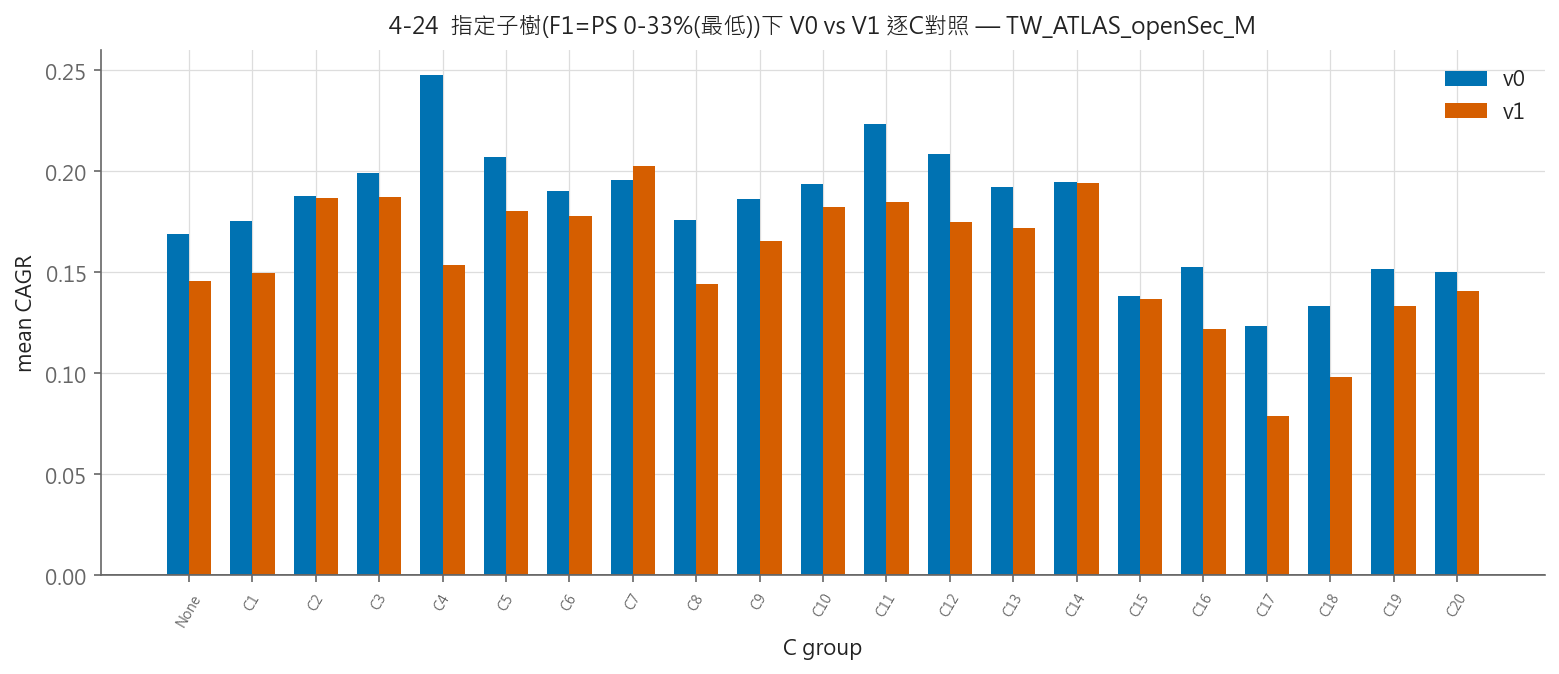

4-2_top10_heatmap.png


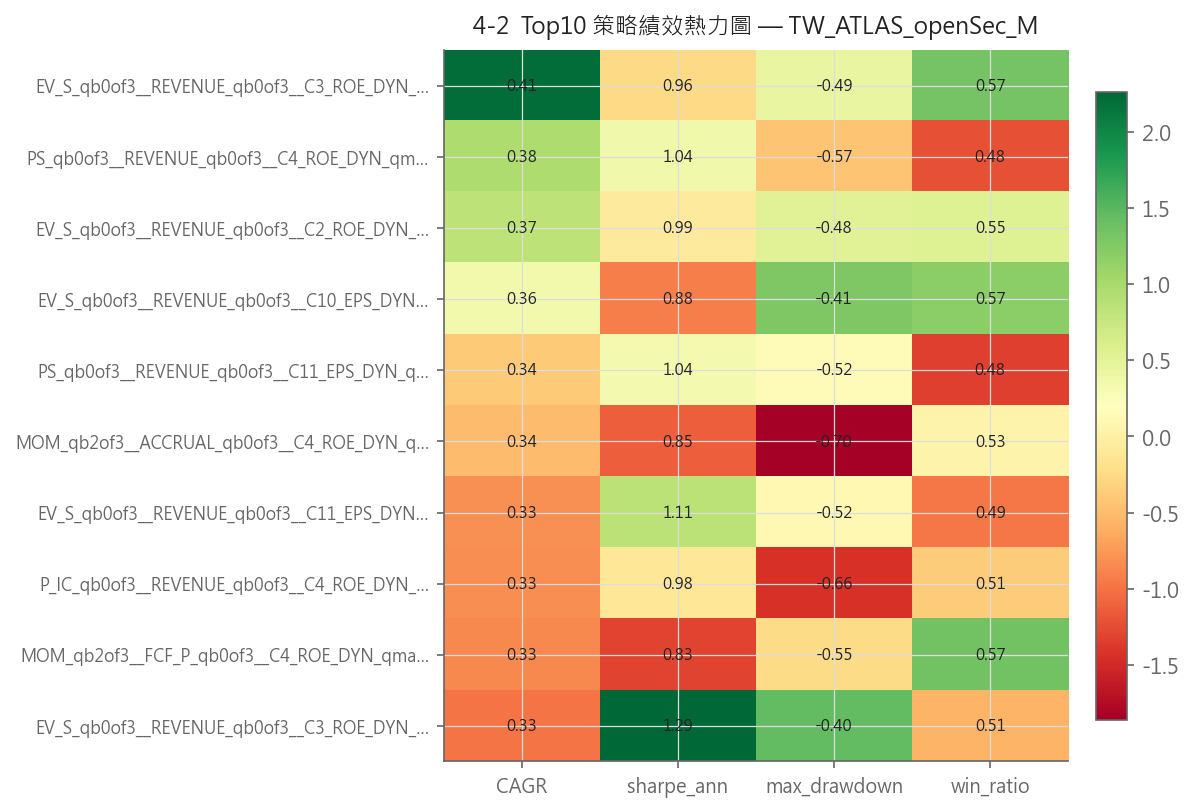

4-3_representative_dissection.png


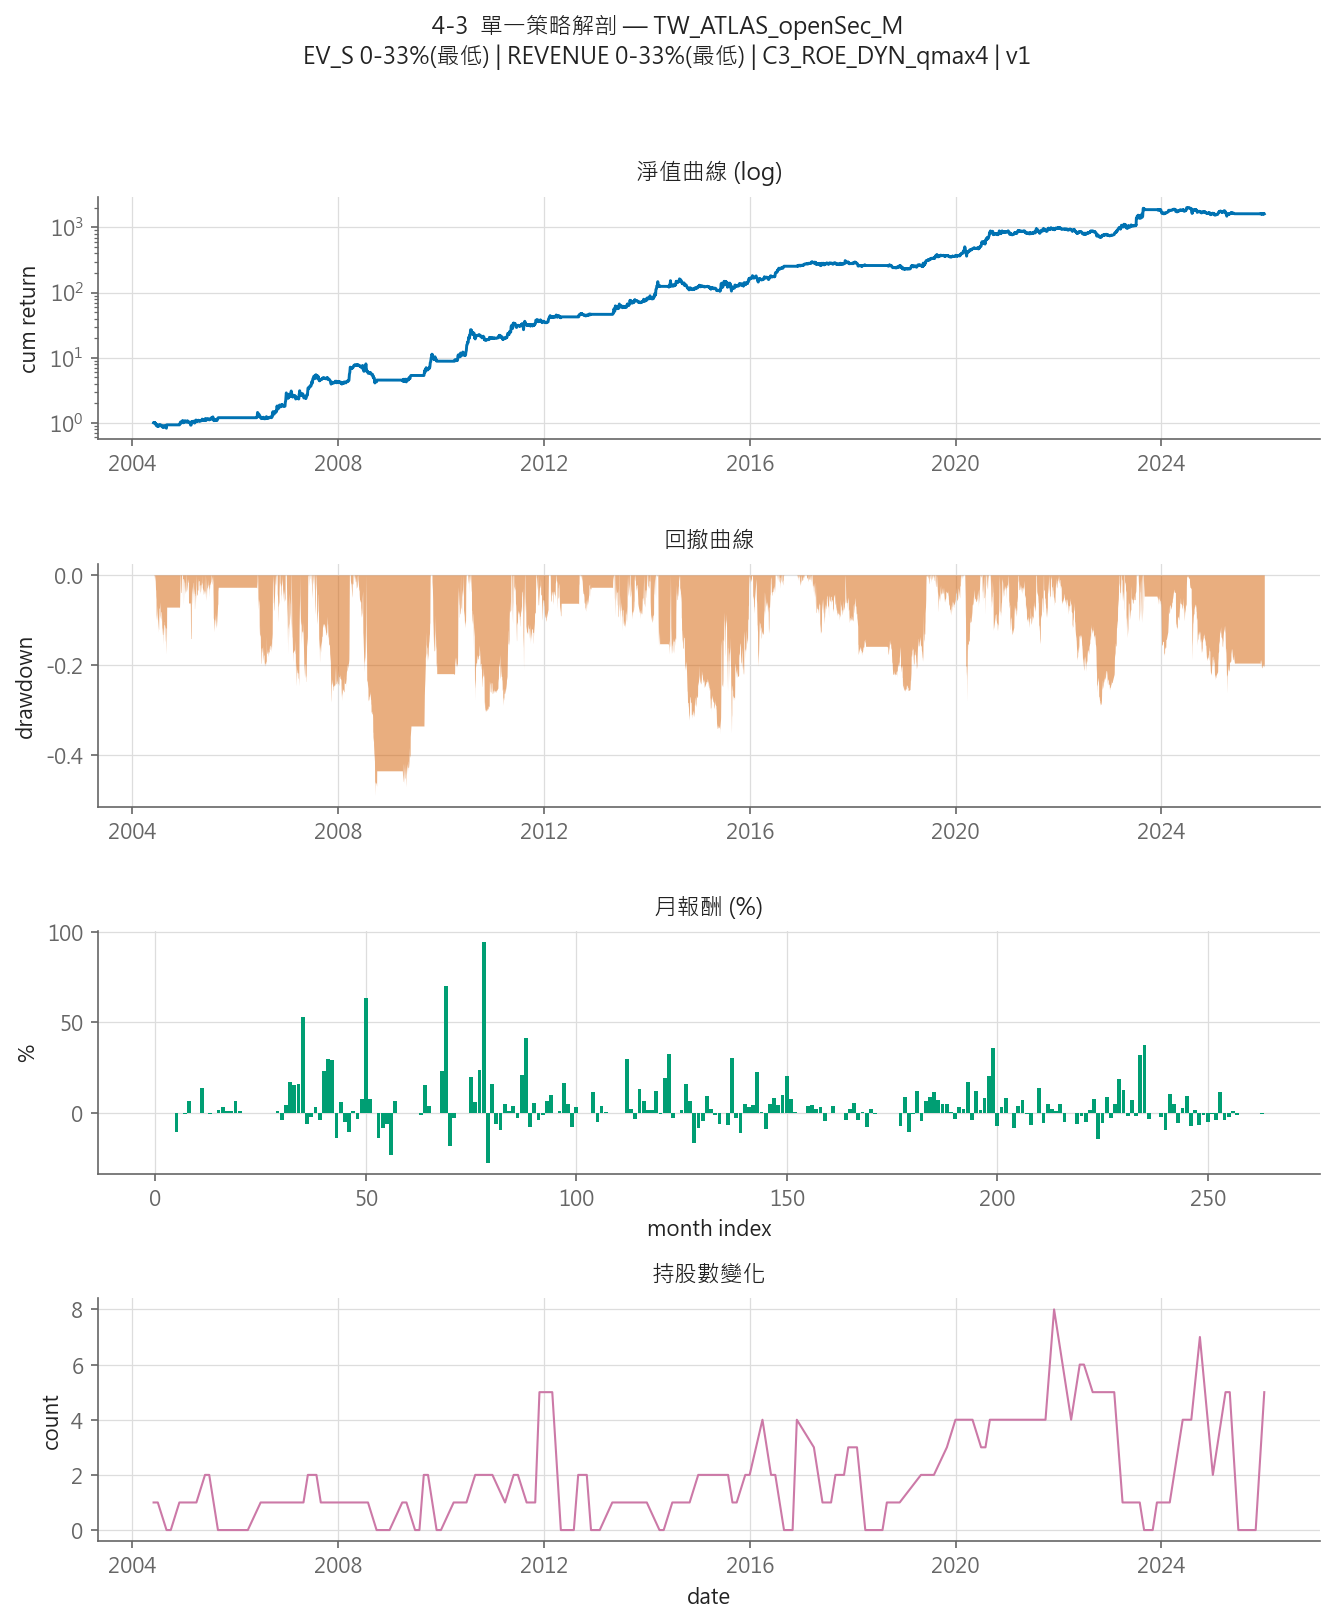

4-4_annual_contribution.png


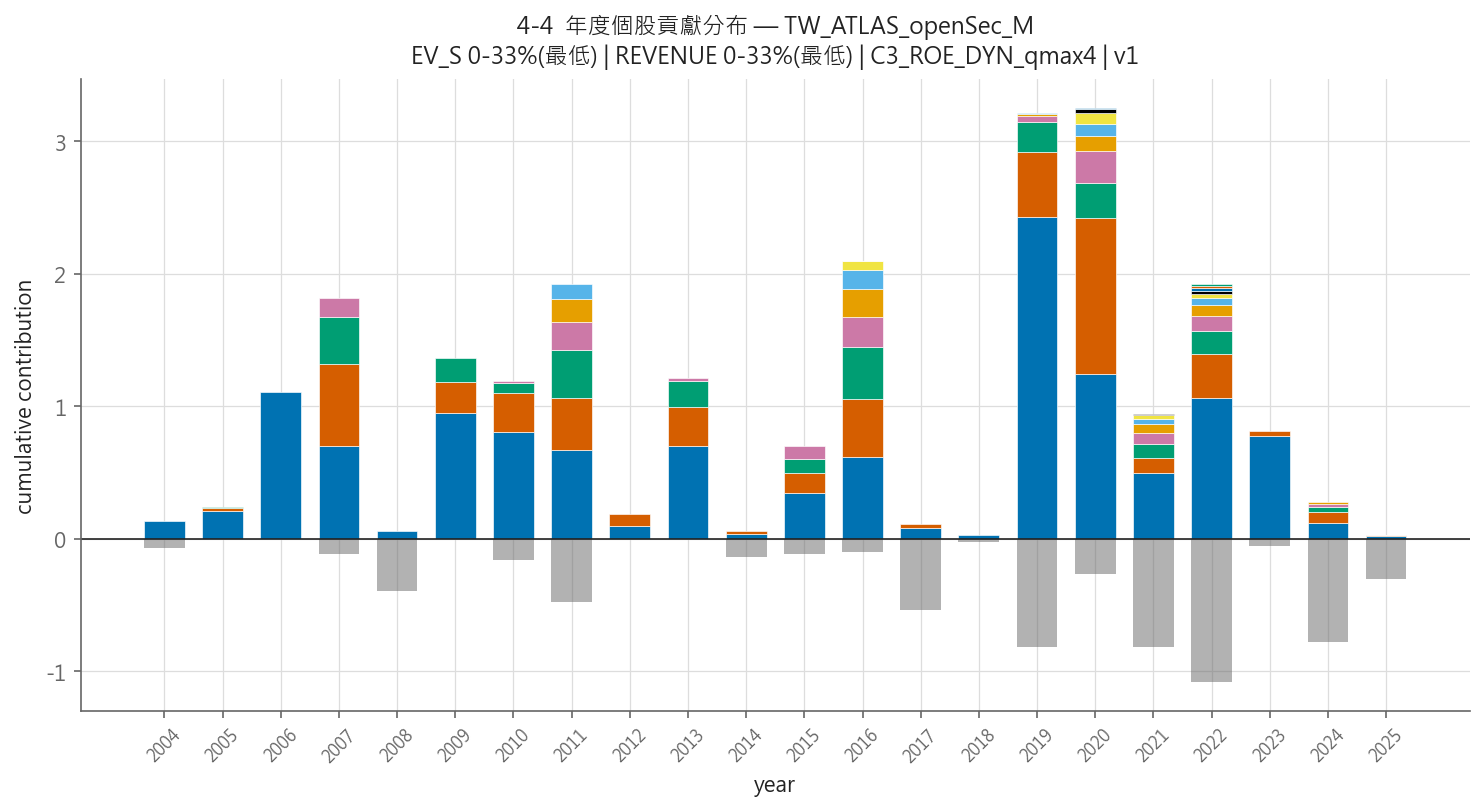

4-5_4-7_top1_frequency.png


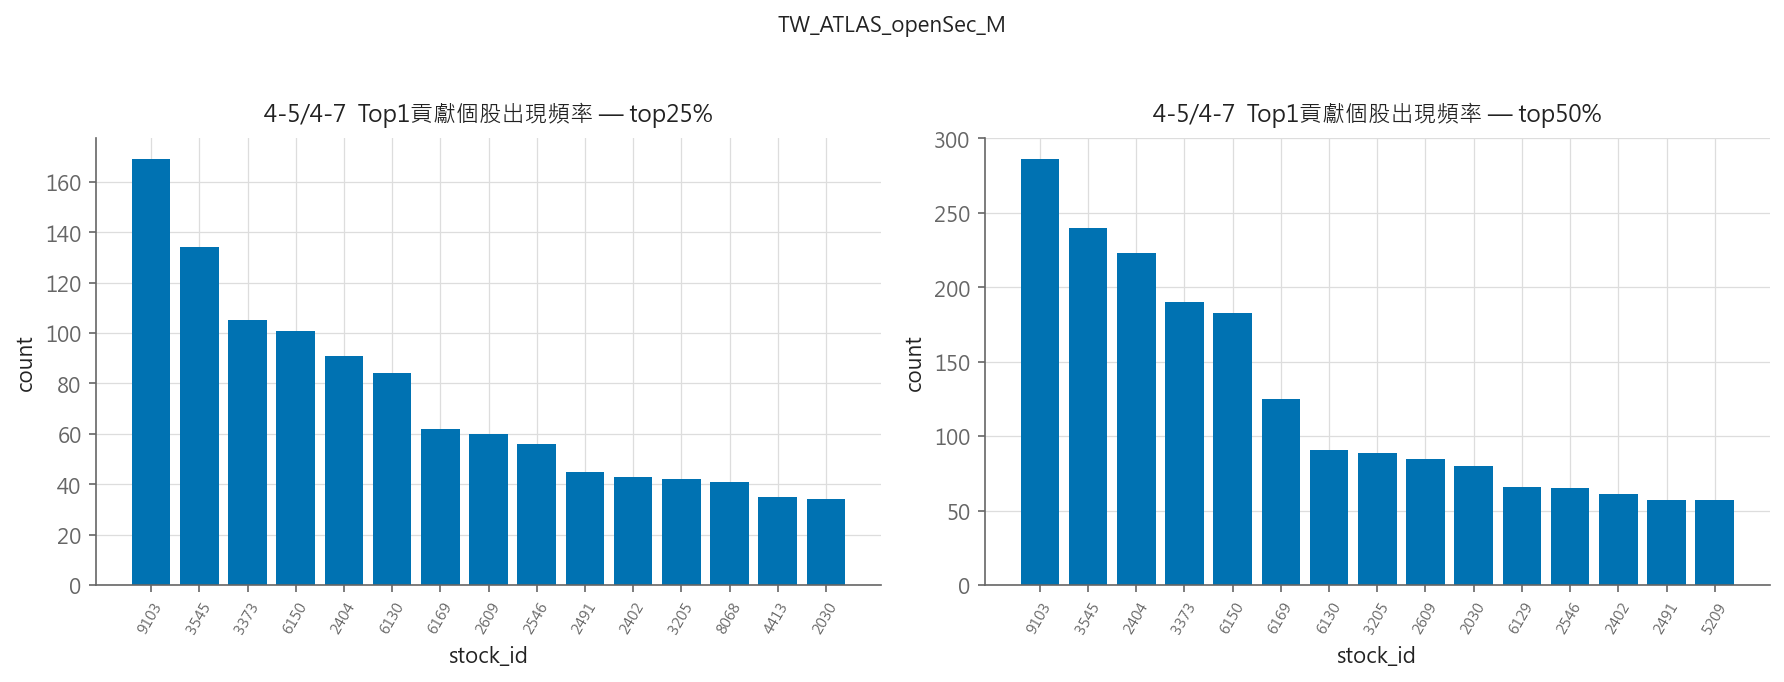

4-6_4-8_top1_share.png


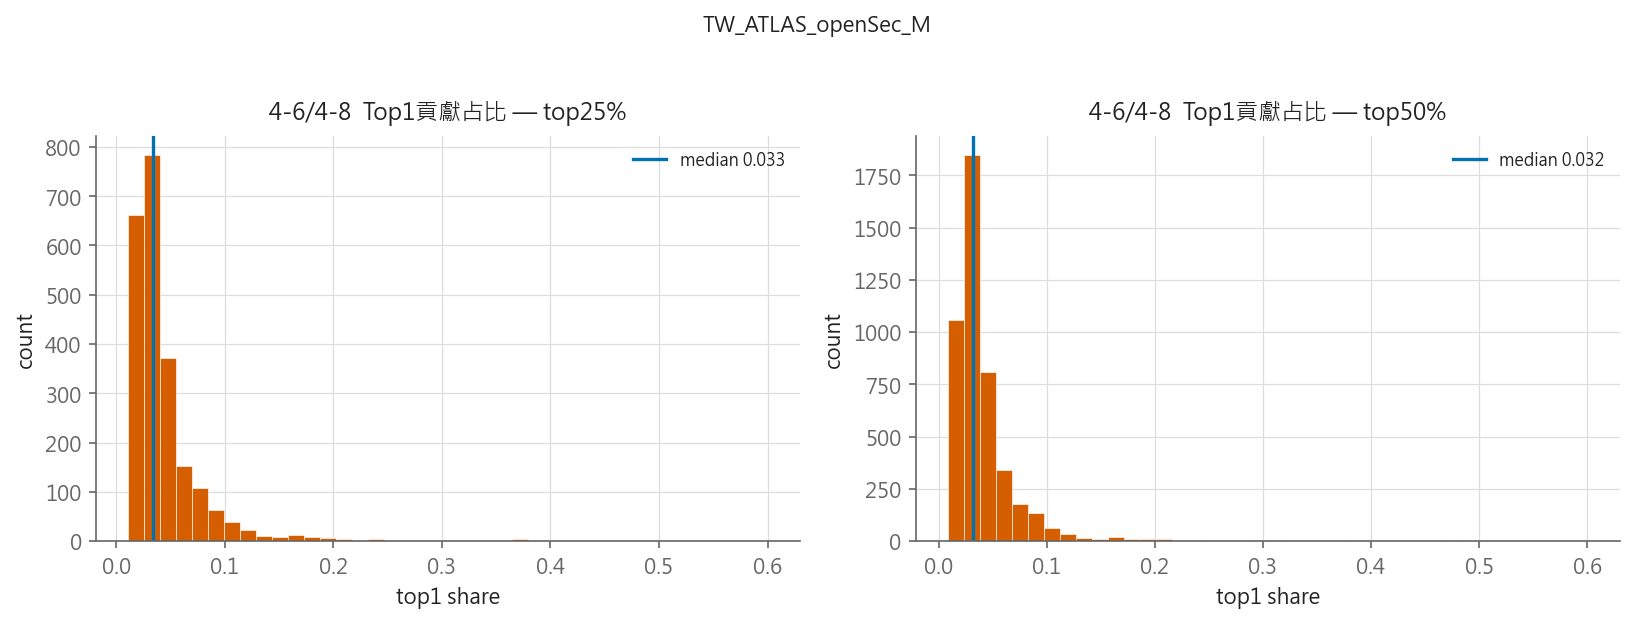

4-9_cumulative_contribution.png


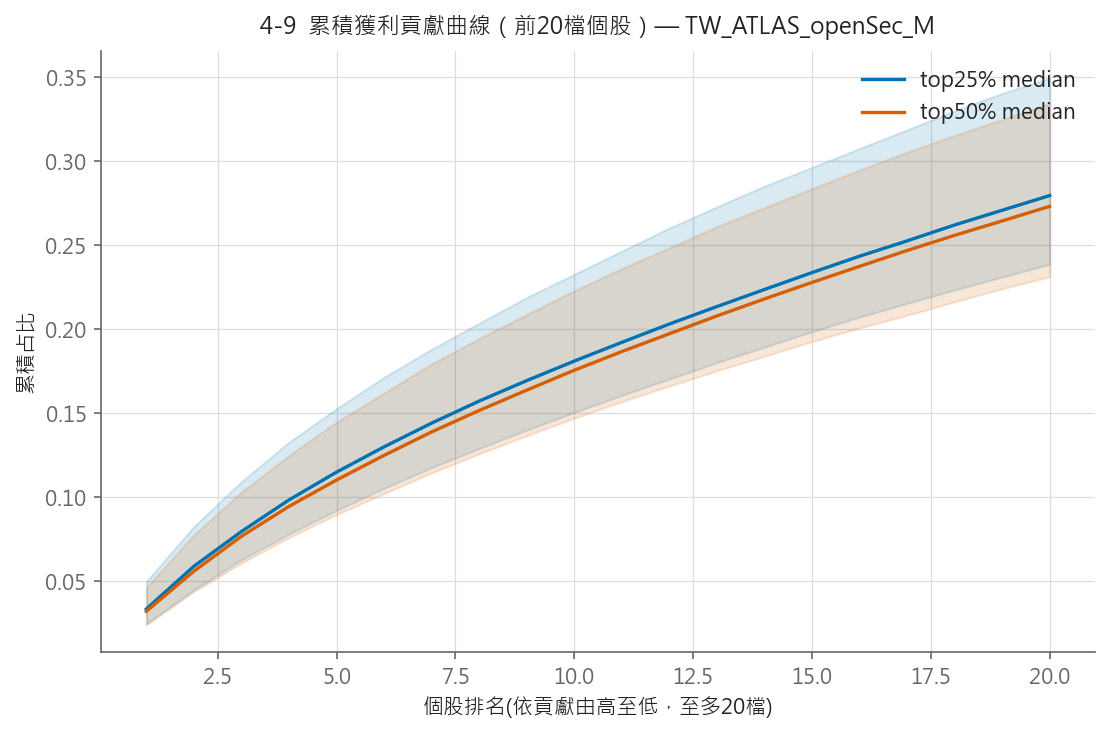

In [65]:
from pathlib import Path

fig_dir = Path(f'../_analysis_outputs_atlas/{MARKET}_openSec{RSFX}/figures')
for p in sorted(fig_dir.glob('*.png')):
    print(p.name)
    display(Image(str(p)))


## 7. 跑完之後

- 每個 Phase 的分析結果都在 `../_analysis_outputs_phase{1,2,3,4}/`，可以跟隨附的
  「參考結果」資料夾對照數字是否一致（同一份程式+同一份資料庫，Phase1-4是確定性
  流程，理論上應完全一致）。
- **切換市場**：改最上面「0.5 選擇市場」那格的 `MARKET` 變數即可，不用逐格修改，其餘流程完全相同。
- **切換日期範圍**：改「0.6 選擇日期範圍」那格的 `START_DATE`/`END_DATE`，並確保「0.7 建立這個
  日期範圍的自建宇宙基準」那格有跑過（analyze腳本都要拿它判「贏不贏大盤」），圖4-16、完整圖鑑
  在內的每一步都會自動套用。維持預設值（2000-01-01~2025-12-31）跟現有正式結果完全相同；
  改成別的範圍會自動存成獨立檔案，不會覆蓋掉正式結果，但 Phase 1~4（含圖4-16、圖鑑）要
  依序用同一組日期重跑一次（跟平常「先跑完前一階段」的順序一樣）。
